# Client Mgas/s Performance vs the 100 Mgas/s Anchor — glamsterdam-devnet-8

#### Maria Silva, September 2026

We collect per-test throughput (`test_mgas_s`) from benchmarkoor for the
`glamsterdam-devnet-8` **stateful** suite and check whether every client sustains
the **100 Mgas/s** anchor on **every** test.

| Suite hash | Suite name | Tests |
| --- | --- | --- |
| `7eec9e8fcd40b131` | `jochemnet-glamsterdam-devnet-8-stateful-full` | 692 |

**Reading the anchor.** Each benchmark fills a block with a target gas value
(200M or 300M here) and benchmarkoor reports `test_mgas_s = test_gas_used / test_time_ns`.
Because it is a rate, it is directly comparable to the anchor regardless of the
block gas value: a test at 100 Mgas/s means the client would execute a 100M gas
block in exactly 1 second. Anything **below** 100 Mgas/s is a test where the
client is slower than the anchor allows.

**Questions:**
1. Which clients sustain ≥ 100 Mgas/s on all tests, and which do not?
2. For the clients that fall short, which tests/operations are responsible?
3. Are the shortfalls universal (all clients slow on the same test → gas
   schedule issue) or client-specific (→ implementation issue)?

In [1]:
import os
import sys
import json
import math
import warnings
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))
src_dir = os.path.join(repo_dir, "src")
sys.path.append(src_dir)

In [3]:
# Credentials for the benchmarkoor API
with open(os.path.join(repo_dir, "secrets.json"), "r") as file:
    secrets_dict = json.load(file)

bearer_token = secrets_dict["benchmarkoor_bearer_token"]

In [4]:
BENCHMARKOOR_BASE_URL = (
    "https://benchmarkoor-api.core.ethpandaops.io/api/v1/index/query"
)

# Suite analysed: jochemnet-glamsterdam-devnet-8-stateful-full
SUITE_HASH = "7eec9e8fcd40b131"

# Throughput anchor every client is expected to sustain on every test
ANCHOR_MGAS_S = 100

PAGE_SIZE = 10_000
CACHE_PATH = os.path.join(
    repo_dir, "data", "mgas_s_glamsterdam_devnet8_stateful.parquet"
)
RUNS_CACHE_PATH = os.path.join(
    repo_dir, "data", "mgas_s_glamsterdam_devnet8_runs.parquet"
)

# Fixed client order so colours/rows are stable across every figure below
CLIENT_ORDER = ["erigon", "geth", "nethermind", "reth"]

## 1. Data collection

`test_stats` on benchmarkoor already exposes `test_mgas_s` per (run, test), so we
do not need to derive throughput ourselves. We pull the whole suite in parallel
pages and cache the raw frame to `data/` — set `USE_CACHE = False` to refresh.

In [5]:
def get_benchmarkoor_session(
    bearer_token: str, count_exact: bool = False
) -> requests.Session:
    """Build a retrying benchmarkoor session, optionally asking for exact row counts."""
    session = requests.Session()
    retries = Retry(total=5, backoff_factor=2, status_forcelist=[502, 503, 524])
    session.mount("https://", HTTPAdapter(max_retries=retries, pool_maxsize=20))
    headers = {"Authorization": f"Bearer {bearer_token}"}
    if count_exact:
        headers["Prefer"] = "count=exact"
    session.headers.update(headers)
    return session


def get_suite_metadata(suite_hash: str, bearer_token: str) -> dict:
    """Return the suite registry row (name, tests_total, indexed_at) for a suite hash."""
    session = get_benchmarkoor_session(bearer_token)
    response = session.get(
        f"{BENCHMARKOOR_BASE_URL}/suites", params={"suite_hash": f"eq.{suite_hash}"}
    )
    response.raise_for_status()
    return response.json()["data"][0]


def get_suite_runs(suite_hash: str, bearer_token: str) -> pd.DataFrame:
    """Return all completed runs of a suite, one row per (client, run)."""
    session = get_benchmarkoor_session(bearer_token)
    params = {
        "select": "run_id,client,image,instance_id,timestamp,tests_total,tests_passed,tests_failed",
        "suite_hash": f"eq.{suite_hash}",
        "status": "eq.completed",
    }
    all_data, offset = [], 0
    while True:
        response = session.get(
            f"{BENCHMARKOOR_BASE_URL}/runs",
            params={**params, "limit": PAGE_SIZE, "offset": offset},
        )
        response.raise_for_status()
        page_data = response.json()["data"]
        all_data.extend(page_data)
        if len(page_data) < PAGE_SIZE:
            break
        offset += PAGE_SIZE
    df = pd.DataFrame(all_data)
    df["run_timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
    return df.drop(columns=["timestamp"])


def get_suite_test_stats(
    suite_hash: str, bearer_token: str, max_workers: int = 8
) -> pd.DataFrame:
    """Fetch every (run, test) throughput row of a suite, paginating in parallel."""
    params = {
        "select": "run_id,client,test_name,test_gas_used,test_time_ns,test_mgas_s,run_start",
        "suite_hash": f"eq.{suite_hash}",
        "test_time_ns": "gt.0",
    }
    count_session = get_benchmarkoor_session(bearer_token, count_exact=True)
    response = count_session.get(
        f"{BENCHMARKOOR_BASE_URL}/test_stats", params={**params, "limit": 0}
    )
    response.raise_for_status()
    total_pages = math.ceil(response.json()["total"] / PAGE_SIZE)
    session = get_benchmarkoor_session(bearer_token)

    def fetch_page(page):
        paginated_params = {**params, "limit": PAGE_SIZE, "offset": page * PAGE_SIZE}
        resp = session.get(
            f"{BENCHMARKOOR_BASE_URL}/test_stats", params=paginated_params
        )
        resp.raise_for_status()
        return page, resp.json()["data"]

    all_data = [None] * total_pages
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(fetch_page, page) for page in range(total_pages)]
        for future in as_completed(futures):
            page, page_data = future.result()
            all_data[page] = page_data
    return pd.DataFrame([row for page_data in all_data for row in page_data])

In [6]:
USE_CACHE = True

if USE_CACHE and os.path.exists(CACHE_PATH):
    raw_df = pd.read_parquet(CACHE_PATH)
    print(f"Loaded cached data from {os.path.relpath(CACHE_PATH, repo_dir)}")
else:
    print(f"Querying benchmarkoor for suite {SUITE_HASH}...")
    raw_df = get_suite_test_stats(SUITE_HASH, bearer_token)
    raw_df.to_parquet(CACHE_PATH)

print(f"{len(raw_df):,} (run, test) throughput measurements")
raw_df.info()

Loaded cached data from data/mgas_s_glamsterdam_devnet8_stateful.parquet
39,444 (run, test) throughput measurements
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39444 entries, 0 to 39443
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   client         39444 non-null  object 
 1   run_id         39444 non-null  object 
 2   run_start      39444 non-null  int64  
 3   test_gas_used  39444 non-null  int64  
 4   test_mgas_s    39444 non-null  float64
 5   test_name      39444 non-null  object 
 6   test_time_ns   39444 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.1+ MB


In [7]:
if USE_CACHE and os.path.exists(RUNS_CACHE_PATH):
    runs_df = pd.read_parquet(RUNS_CACHE_PATH)
else:
    runs_df = get_suite_runs(SUITE_HASH, bearer_token)
    runs_df.to_parquet(RUNS_CACHE_PATH)

meta = get_suite_metadata(SUITE_HASH, bearer_token)
print(f"{meta['suite_hash']}  {meta['name']}  ({meta['tests_total']} tests)")
print(
    f"\nRuns from {runs_df['run_timestamp'].min():%Y-%m-%d %H:%M} "
    f"to {runs_df['run_timestamp'].max():%Y-%m-%d %H:%M} UTC"
)
display(
    runs_df.groupby(["client", "image", "instance_id"]).agg(
        n_runs=("run_id", "size"),
        tests_total=("tests_total", "max"),
        tests_failed=("tests_failed", "sum"),
        last_run=("run_timestamp", "max"),
    )
)

7eec9e8fcd40b131  jochemnet-glamsterdam-devnet-8-stateful-full  (692 tests)

Runs from 2026-08-28 18:50 to 2026-09-01 05:24 UTC


,,,n_runs,tests_total,tests_failed,last_run
client,image,instance_id,,,,
erigon,ethpandaops/erigon:glamsterdam-devnet-8,erigon-bal-full,12,692,0,2026-08-31 23:47:34
geth,ethpandaops/geth:glamsterdam-devnet-8,geth-bal-full,18,692,0,2026-09-01 05:24:01
nethermind,ethpandaops/nethermind:glamsterdam-devnet-8,nethermind-bal-full,14,692,0,2026-09-01 05:12:03
reth,ethpandaops/reth:glamsterdam-devnet-8,reth-bal-full,13,692,0,2026-09-01 02:47:00


Only four clients run this suite — `besu` and `ethrex`, which were present in the
devnet-7 analysis, have no completed devnet-8 stateful runs. The data is
otherwise much cleaner than devnet-7: every client runs a single pinned
`glamsterdam-devnet-8` image on its own dedicated instance, **passes all 692
tests in every run**, and the number of repetitions is comparable across clients
(12-18 runs). We still aggregate to a **per-test median across runs** before
comparing to the anchor, so the client with more repetitions is not penalised by
extra tail noise.

In [8]:
def parse_test_name(prev_df: pd.DataFrame) -> pd.DataFrame:
    """Split the benchmarkoor test_name into file, function, params and flags."""
    df = prev_df.copy()
    df["test_file"] = (
        df["test_name"].str.split("::").str[0].str.replace("benchmark/", "")
    )
    df["test_func"] = df["test_name"].str.split("::").str[1].str.split("[").str[0]
    df["test_params"] = df["test_name"].str.split("[").str[1].str.rstrip("]")
    df["test_category"] = df["test_file"].str.split("/").str[1]
    # Target block gas value the benchmark was filled to (e.g. "gas-value_200M")
    df["gas_value_m"] = (
        df["test_params"].str.extract(r"gas-value_(\d+)M")[0].astype(float)
    )
    # Baseline variants measure the harness overhead, not a full worst-case block
    df["is_baseline"] = df["test_params"].str.contains("overhead_baseline_True")
    return df


raw_df = parse_test_name(raw_df)
raw_df[["client", "test_category", "test_func", "gas_value_m", "is_baseline"]].head()

,client,test_category,test_func,gas_value_m,is_baseline
0,reth,bloatnet,test_sstore_dirty_transitions,200.0,False
1,reth,bloatnet,test_account_access,200.0,True
2,reth,bloatnet,test_sstore_dirty_transitions,200.0,False
3,reth,bloatnet,test_account_access,200.0,True
4,reth,bloatnet,test_account_access,200.0,True


### Separating the overhead-baseline variants

Some tests come in an `overhead_baseline_True` flavour. These are calibration
blocks used to subtract harness overhead — they are filled to only ~7M gas
instead of 200-300M, so their Mgas/s is not a worst-case block throughput and
should not be judged against the anchor. We keep them aside and report them
separately.

In [9]:
display(
    raw_df.groupby("is_baseline").agg(
        n_tests=("test_name", "nunique"),
        n_measurements=("test_name", "size"),
        median_gas_used=("test_gas_used", "median"),
    )
)
display(
    raw_df.groupby(["test_category", "test_func"]).agg(
        n_tests=("test_name", "nunique"),
        n_measurements=("test_name", "size"),
    )
)

,n_tests,n_measurements,median_gas_used
is_baseline,,,
False,532,30324,226069407.0
True,160,9120,6943114.0


n_tests  n_measurements
test_category test_func                                                      
bloatnet      test_account_access                         400           22800
              test_call_value_to_empty                      2             114
              test_create2_immediate_access                18            1026
              test_ether_transfers_onchain_receivers       72            4104
              test_ext_account_query_warm                 112            6384
              test_sload_benchmark                          8             456
              test_sload_bloated                            4             228
              test_sload_bloated_multi_contract             4             228
              test_sload_same_key_benchmark                 4             228
              test_sstore_bloated                           8             456
              test_sstore_dirty_transitions                20            1140
              test_sstore_variants                         32            1824
              test_tstore_same_key                          4             228
              test_tstore_unique_keys                       4             228

## 2. Per-test, per-client throughput

For each (client, test) we take the **median** Mgas/s across runs as the central
estimate and the **minimum** as the worst observed case. The `headroom` column is
`median / 100` — values below 1 are tests where the client misses the anchor.

In [10]:
by_test_df = (
    raw_df.groupby(
        [
            "test_category",
            "test_func",
            "test_name",
            "test_params",
            "gas_value_m",
            "is_baseline",
            "client",
        ]
    )["test_mgas_s"]
    .agg(["median", "min", "max", "count"])
    .reset_index()
    .rename(
        columns={
            "median": "median_mgas_s",
            "min": "min_mgas_s",
            "max": "max_mgas_s",
            "count": "n_runs",
        }
    )
)
by_test_df["headroom"] = by_test_df["median_mgas_s"] / ANCHOR_MGAS_S
by_test_df["below_anchor"] = by_test_df["median_mgas_s"] < ANCHOR_MGAS_S
by_test_df["below_anchor_worst_case"] = by_test_df["min_mgas_s"] < ANCHOR_MGAS_S

# Main frame for the anchor assessment: real worst-case blocks only
main_df = by_test_df[~by_test_df["is_baseline"]]
baseline_df = by_test_df[by_test_df["is_baseline"]]

print(f"{len(main_df):,} (client, test) pairs assessed against the anchor")
display(main_df.head())

2,128 (client, test) pairs assessed against the anchor


,test_category,test_func,test_name,test_params,gas_value_m,is_baseline,client,median_mgas_s,min_mgas_s,max_mgas_s,n_runs,headroom,below_anchor,below_anchor_worst_case
0,bloatnet,test_account_access,benchmark/stateful/bloatnet/test_account_query...,fork_Amsterdam-blockchain_test_stateful_engine...,200.0,False,erigon,257.115850,252.822850,261.390455,12,2.571158,False,False
1,bloatnet,test_account_access,benchmark/stateful/bloatnet/test_account_query...,fork_Amsterdam-blockchain_test_stateful_engine...,200.0,False,geth,139.989521,133.863688,145.690051,18,1.399895,False,False
2,bloatnet,test_account_access,benchmark/stateful/bloatnet/test_account_query...,fork_Amsterdam-blockchain_test_stateful_engine...,200.0,False,nethermind,549.098737,498.150461,593.239444,14,5.490987,False,False
3,bloatnet,test_account_access,benchmark/stateful/bloatnet/test_account_query...,fork_Amsterdam-blockchain_test_stateful_engine...,200.0,False,reth,152.925561,150.768942,160.504290,13,1.529256,False,False
4,bloatnet,test_account_access,benchmark/stateful/bloatnet/test_account_query...,fork_Amsterdam-blockchain_test_stateful_engine...,300.0,False,erigon,293.585900,285.036330,295.086839,12,2.935859,False,False


In [11]:
display(
    main_df.groupby("client")["median_mgas_s"]
    .agg(["count", "min", "median", "max"])
    .round(1)
    .reindex(CLIENT_ORDER)
)

,count,min,median,max
client,,,,
erigon,532,8.6,521.4,9254.1
geth,532,49.6,148.3,12419.6
nethermind,532,59.5,537.0,7203.7
reth,532,63.2,603.9,27209.9


No client is missing any test, so all four are assessed over exactly the same 532
non-baseline (client, test) pairs.

In [12]:
missing_tests = {
    client: sorted(
        set(main_df["test_name"])
        - set(main_df[main_df["client"] == client]["test_name"])
    )
    for client in CLIENT_ORDER
}
for client, tests in missing_tests.items():
    print(f"{client}: {len(tests)} tests missing")

erigon: 0 tests missing
geth: 0 tests missing
nethermind: 0 tests missing
reth: 0 tests missing


## 3. Headline: who clears the anchor?

In [13]:
anchor_summary = (
    main_df.groupby("client")
    .agg(
        n_tests=("test_name", "size"),
        n_below=("below_anchor", "sum"),
        n_below_worst_case=("below_anchor_worst_case", "sum"),
        slowest_mgas_s=("median_mgas_s", "min"),
    )
    .reindex(CLIENT_ORDER)
    .reset_index()
)
anchor_summary["pct_below"] = (
    100 * anchor_summary["n_below"] / anchor_summary["n_tests"]
).round(1)
anchor_summary["pct_below_worst_case"] = (
    100 * anchor_summary["n_below_worst_case"] / anchor_summary["n_tests"]
).round(1)
anchor_summary["slowest_mgas_s"] = anchor_summary["slowest_mgas_s"].round(1)

display(anchor_summary.set_index("client"))

,n_tests,n_below,n_below_worst_case,slowest_mgas_s,pct_below,pct_below_worst_case
client,,,,,,
erigon,532,129,131,8.6,24.2,24.6
geth,532,100,111,49.6,18.8,20.9
nethermind,532,60,79,59.5,11.3,14.8
reth,532,32,32,63.2,6.0,6.0


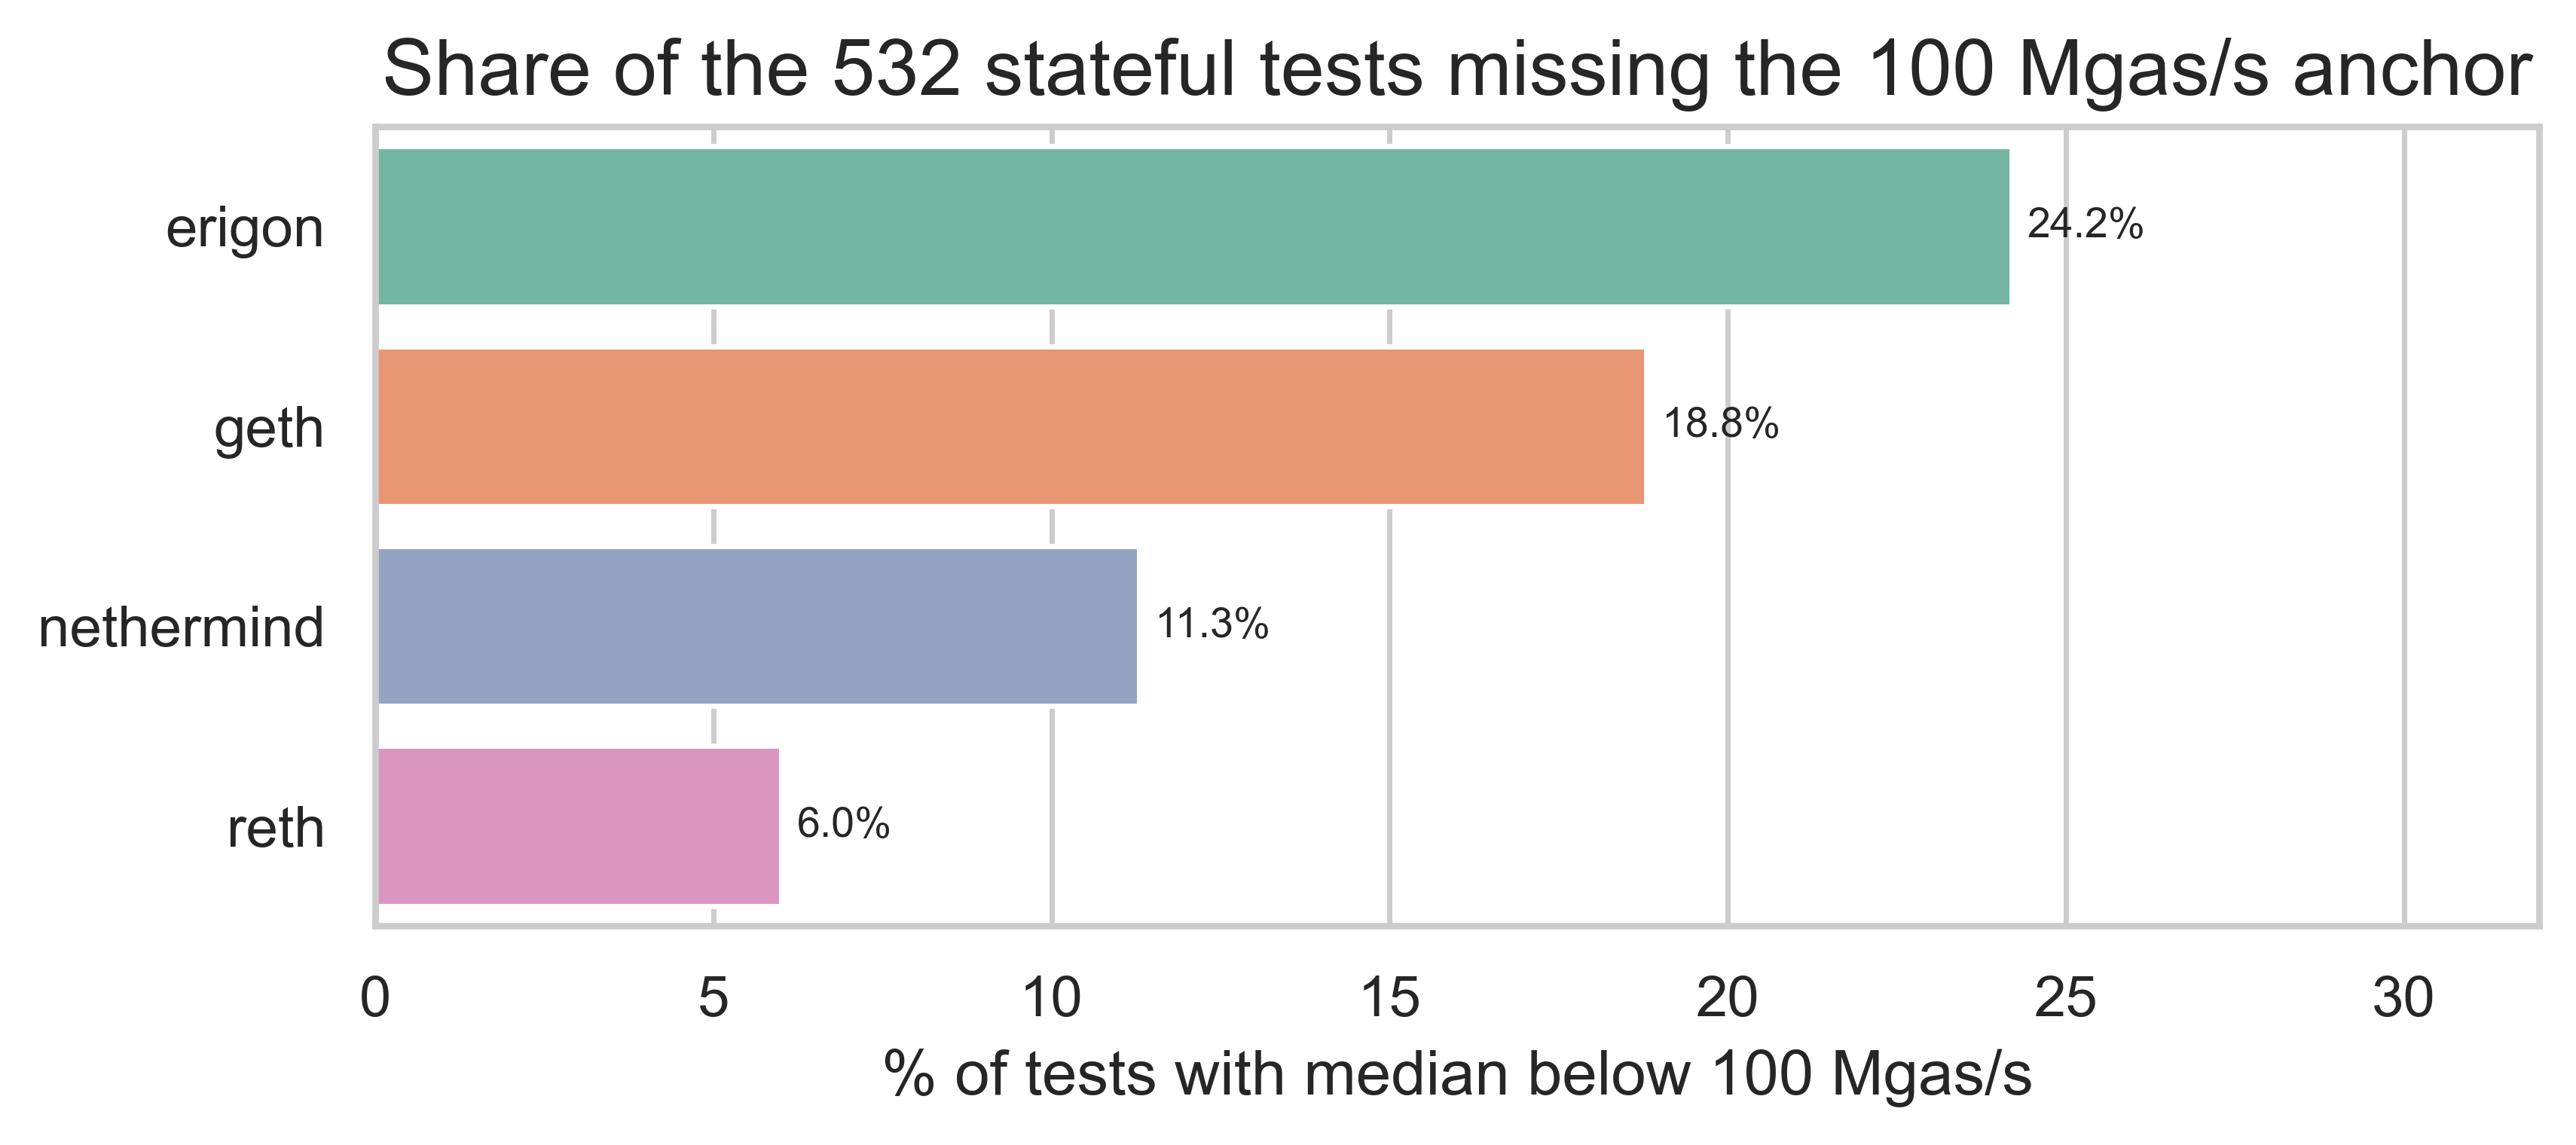

In [14]:
fig, ax = plt.subplots(figsize=(7, 3.2))
sns.barplot(
    data=anchor_summary,
    y="client",
    x="pct_below",
    hue="client",
    order=CLIENT_ORDER,
    legend=False,
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)
n_tests = anchor_summary["n_tests"].max()
ax.set_xlabel(f"% of tests with median below {ANCHOR_MGAS_S} Mgas/s")
ax.set_ylabel("")
ax.set_xlim(0, 32)
ax.set_title(
    f"Share of the {n_tests} stateful tests missing the {ANCHOR_MGAS_S} Mgas/s anchor"
)
plt.tight_layout()
plt.show()

**No client clears the anchor on every test.** `reth` is closest (32 of 532
tests, 6.0%), followed by `nethermind` (60, 11.3%), `geth` (100, 18.8%) and
`erigon` (129, 24.2%). Note this is a stateful-only suite: on devnet-7 the
compute suite was essentially clean, and all the pressure came from the stateful
side — the same holds here, only measured against a 33% higher anchor.

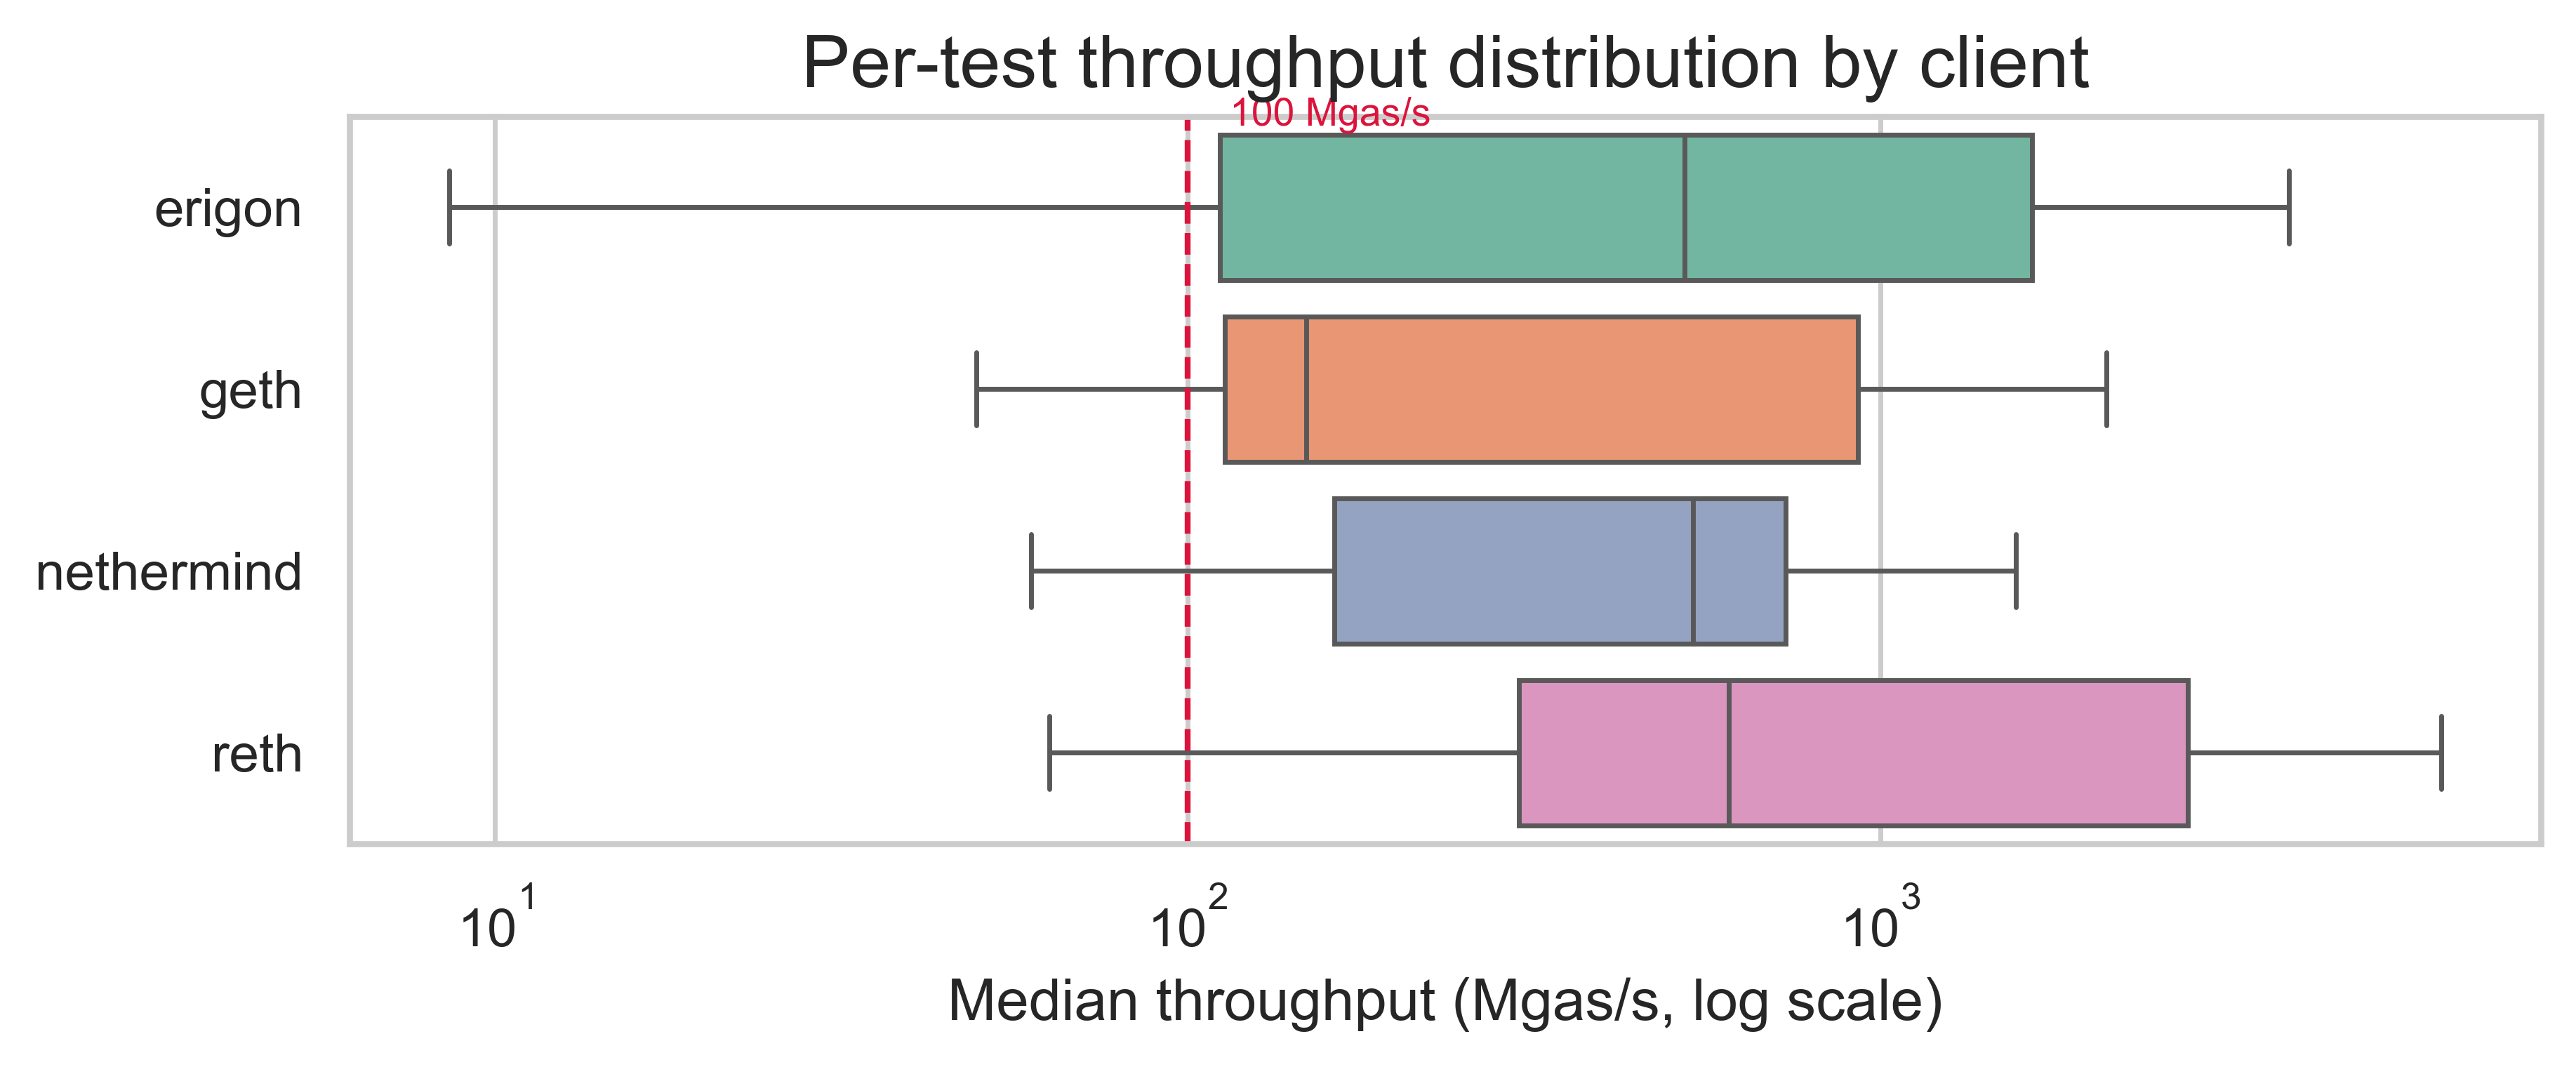

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
sns.boxplot(
    data=main_df,
    y="client",
    x="median_mgas_s",
    hue="client",
    order=CLIENT_ORDER,
    legend=False,
    showfliers=False,
    ax=ax,
)
ax.axvline(ANCHOR_MGAS_S, color="crimson", linestyle="--", linewidth=1.2)
ax.text(
    ANCHOR_MGAS_S * 1.15,
    -0.45,
    f"{ANCHOR_MGAS_S} Mgas/s",
    color="crimson",
    fontsize=8,
)
ax.set_xscale("log")
ax.set_xlabel("Median throughput (Mgas/s, log scale)")
ax.set_ylabel("")
ax.set_title("Per-test throughput distribution by client")
plt.tight_layout()
plt.show()

The medians sit one to two orders of magnitude above the anchor (148 Mgas/s for
`geth`, 521-604 for the others), so the anchor is not a broad throughput problem
— it is a **tail** problem. The plot below zooms into the bottom of each
distribution.

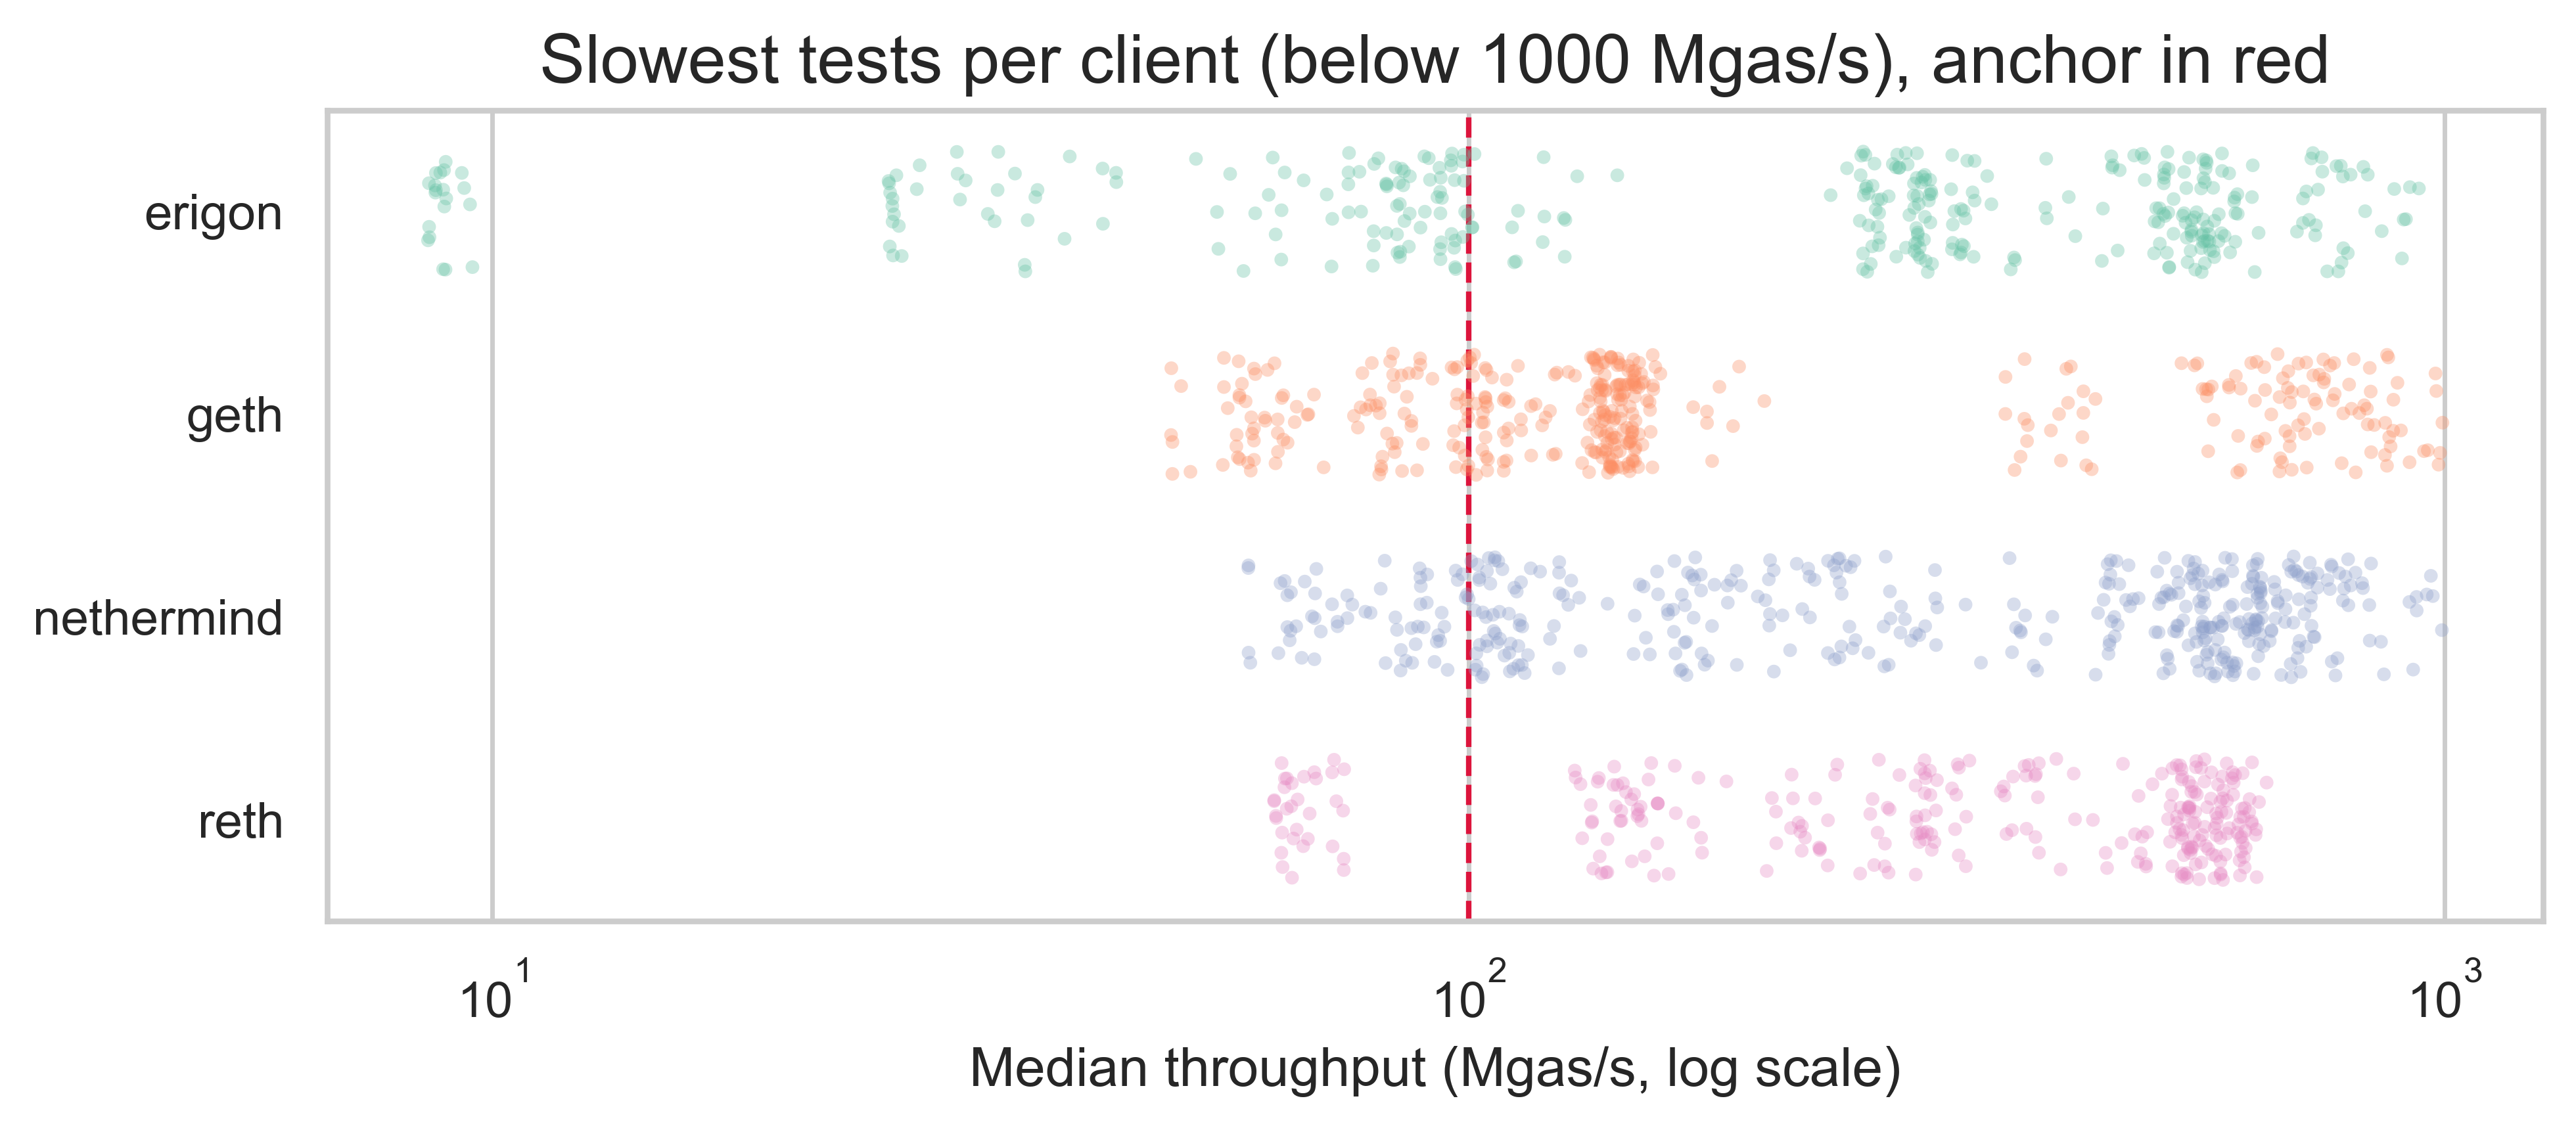

In [16]:
plot_df = main_df[main_df["median_mgas_s"] < 1000]

fig, ax = plt.subplots(figsize=(8, 3.6))
sns.stripplot(
    data=plot_df,
    y="client",
    x="median_mgas_s",
    hue="client",
    order=CLIENT_ORDER,
    alpha=0.35,
    size=3,
    jitter=0.3,
    legend=False,
    ax=ax,
)
ax.axvline(ANCHOR_MGAS_S, color="crimson", linestyle="--", linewidth=1.2)
ax.set_xscale("log")
ax.set_xlabel("Median throughput (Mgas/s, log scale)")
ax.set_ylabel("")
ax.set_title("Slowest tests per client (below 1000 Mgas/s), anchor in red")
plt.tight_layout()
plt.show()

## 4. Where the anchor breaks

We break the shortfalls down by test function.

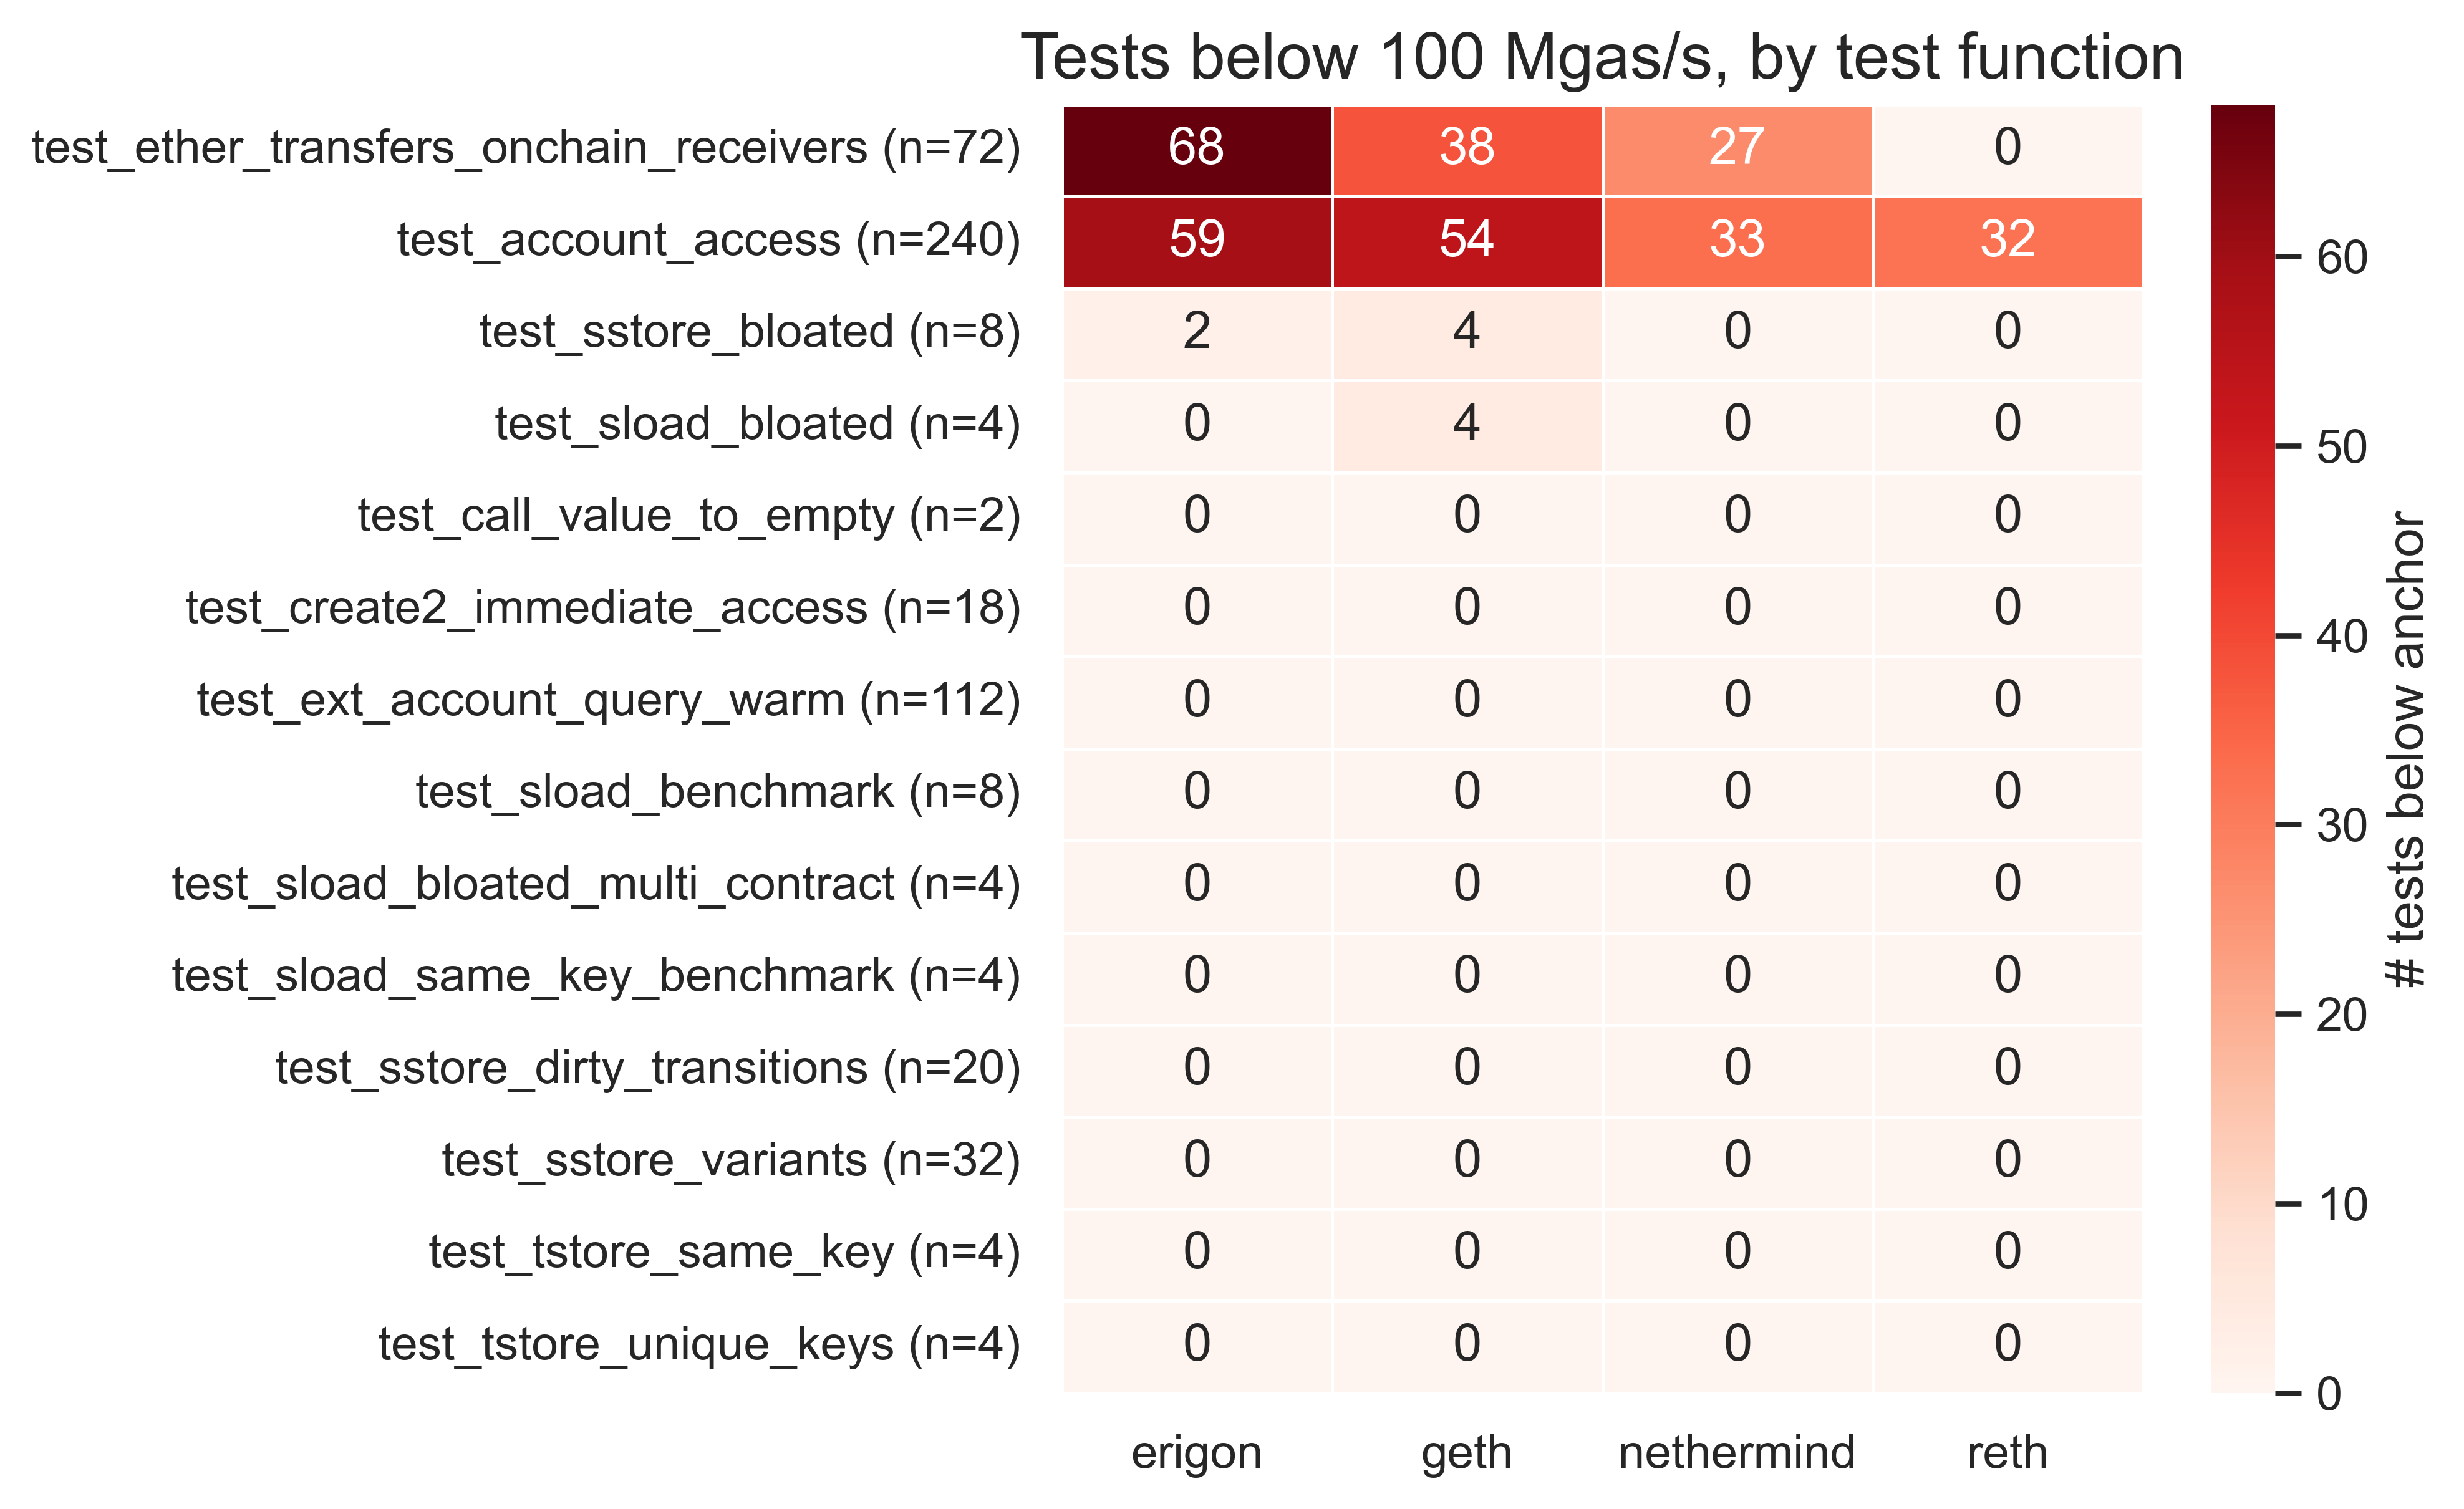

In [17]:
func_pivot = main_df.pivot_table(
    index="test_func", columns="client", values="below_anchor", aggfunc="sum"
).reindex(columns=CLIENT_ORDER)
func_pivot["n_tests"] = main_df.groupby("test_func")["test_name"].nunique()
func_pivot = func_pivot.sort_values(CLIENT_ORDER, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    func_pivot[CLIENT_ORDER],
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "# tests below anchor"},
    ax=ax,
)
ax.set_yticklabels(
    [
        f"{i.get_text()} (n={func_pivot.loc[i.get_text(), 'n_tests']})"
        for i in ax.get_yticklabels()
    ],
    rotation=0,
)
ax.set_title(f"Tests below {ANCHOR_MGAS_S} Mgas/s, by test function")
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

Almost every shortfall lives in two test functions — `test_account_access`
(240 tests) and `test_ether_transfers_onchain_receivers` (72 tests). The only
other misses are a handful of bloated-storage cases for `geth` (4 `sload_bloated`,
4 `sstore_bloated`) and `erigon` (2 `sstore_bloated`). Warm account queries
(`ext_account_query_warm`, 112 tests), `create2_immediate_access`, the
`sstore_variants`/`dirty_transitions` families and all `tstore_*` benchmarks
clear the anchor on every client.

### 4.1 `test_account_access` — cold access to large-code contracts

Unlike devnet-7, every `test_account_access` case in this suite uses the
`NO_CACHE` cache strategy, so there is no warm comparison to fall back on.
The parameterisation instead varies the **contract code size** (24,576 vs 65,536
bytes), the account mode, the opcode and whether value is sent.

In [18]:
account_access_df = main_df[main_df["test_func"] == "test_account_access"].copy()
for param in ["cache_strategy", "account_mode", "opcode", "value_sent", "code_size"]:
    account_access_df[param] = account_access_df["test_params"].str.extract(
        rf"{param}_([^-]+)"
    )
account_access_df["cache_strategy"] = account_access_df["cache_strategy"].str.replace(
    "CacheStrategy.", "", regex=False
)
account_access_df["account_mode"] = account_access_df["account_mode"].str.replace(
    "AccountMode.", "", regex=False
)

display(
    account_access_df.pivot_table(
        index="account_mode",
        columns="client",
        values=["below_anchor", "median_mgas_s"],
        aggfunc={"below_anchor": "sum", "median_mgas_s": "min"},
    ).round(1)
)

below_anchor                      median_mgas_s  \
client                           erigon geth nethermind reth        erigon   
account_mode                                                                 
EXISTING_CONTRACT_DIFF_MAX           28   28         12   16           8.7   
EXISTING_CONTRACT_JUMPDEST           26   26         21   16           8.6   
EXISTING_CONTRACT_MINIMAL             0    0          0    0         100.9   
EXISTING_CONTRACT_SAME_MAX            1    0          0    0          99.9   
EXISTING_EOA                          4    0          0    0          84.2   
NON_EXISTING_ACCOUNT                  0    0          0    0         456.5   

                                                     
client                       geth nethermind   reth  
account_mode                                         
EXISTING_CONTRACT_DIFF_MAX   49.6       63.9   63.2  
EXISTING_CONTRACT_JUMPDEST   56.0       59.5   63.5  
EXISTING_CONTRACT_MINIMAL   112.4      203.1  354.5  
EXISTING_CONTRACT_SAME_MAX  113.3      197.9  351.1  
EXISTING_EOA                116.0      205.5  353.5  
NON_EXISTING_ACCOUNT        126.6      640.9  537.7

**All the damage is in two account modes.** `EXISTING_CONTRACT_DIFF_MAX` and
`EXISTING_CONTRACT_JUMPDEST` — the modes that force a real trie lookup against a
large contract — account for essentially every miss. `EXISTING_CONTRACT_MINIMAL`,
`EXISTING_CONTRACT_SAME_MAX`, `EXISTING_EOA` and `NON_EXISTING_ACCOUNT` clear the
anchor everywhere except for five marginal `erigon` cases.

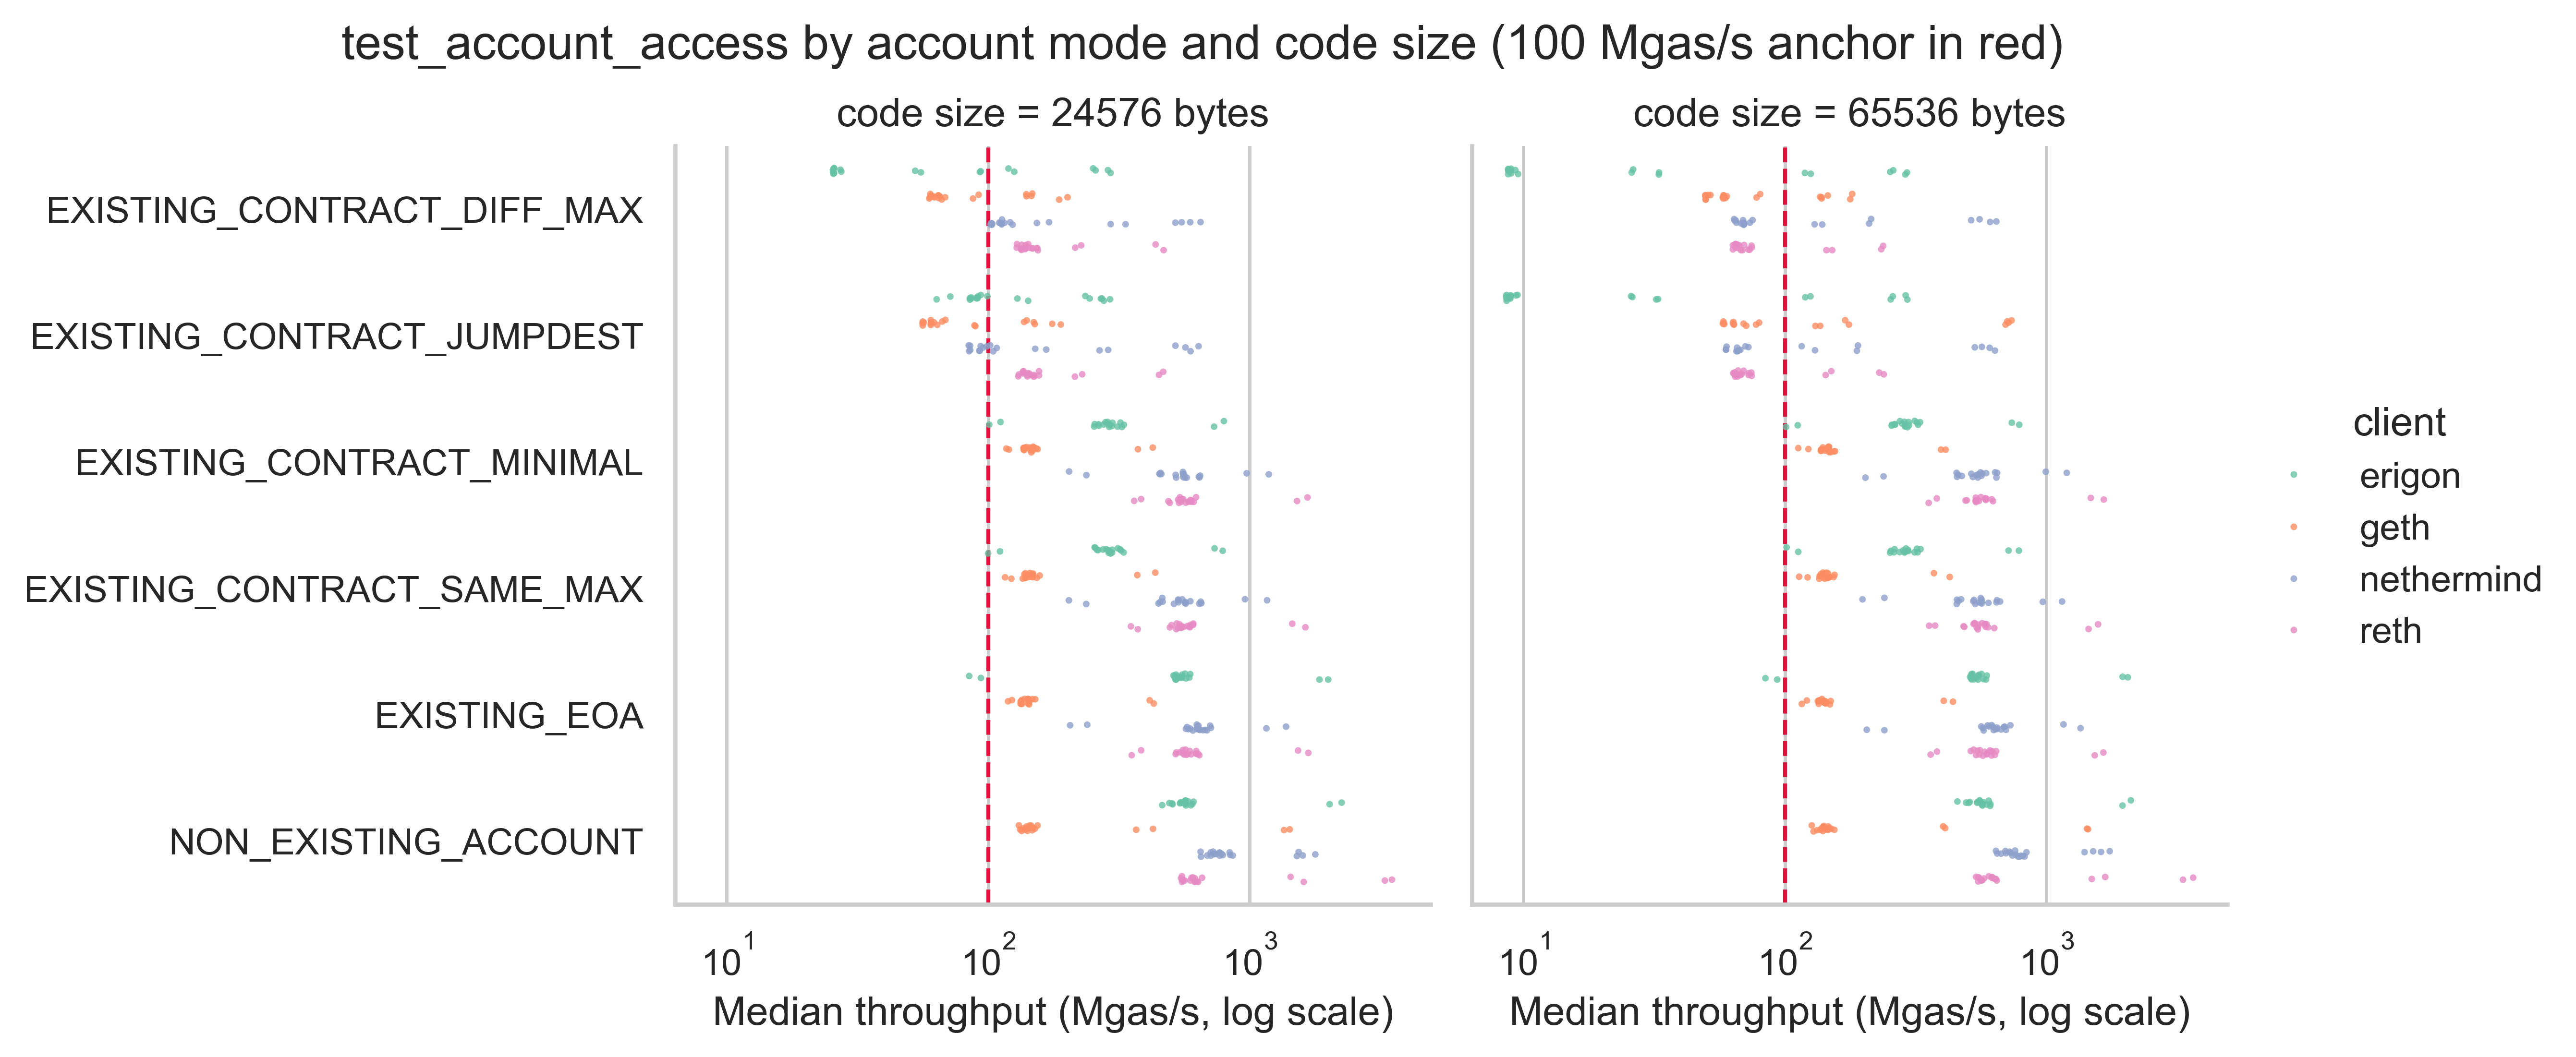

In [19]:
g = sns.catplot(
    data=account_access_df,
    y="account_mode",
    x="median_mgas_s",
    hue="client",
    hue_order=CLIENT_ORDER,
    col="code_size",
    kind="strip",
    dodge=True,
    height=4.2,
    aspect=1.2,
    s=4,
    alpha=0.8,
)
for ax in g.axes.flat:
    ax.axvline(ANCHOR_MGAS_S, color="crimson", linestyle="--", linewidth=1.2)
    ax.set_xscale("log")
g.set_titles("code size = {col_name} bytes")
g.set_xlabels("Median throughput (Mgas/s, log scale)")
g.set_ylabels("")
g.figure.suptitle(
    f"test_account_access by account mode and code size "
    f"({ANCHOR_MGAS_S} Mgas/s anchor in red)",
    y=1.03,
)
plt.show()

In [20]:
display(
    account_access_df.pivot_table(
        index="code_size",
        columns="client",
        values=["below_anchor", "median_mgas_s"],
        aggfunc={"below_anchor": "sum", "median_mgas_s": "min"},
    ).round(1)
)

below_anchor                      median_mgas_s                   \
client          erigon geth nethermind reth        erigon  geth nethermind   
code_size                                                                    
24576               29   28          9    0          25.5  56.0       84.2   
65536               30   26         24   32           8.6  49.6       59.5   

                  
client      reth  
code_size         
24576      128.5  
65536       63.2

**Code size is the new discriminator.** All 32 of `reth`'s misses are at the
65,536-byte code size — it clears every single 24,576-byte case. `nethermind` is
similar (24 misses at 65,536 vs 9 at 24,576). `erigon` and `geth` are hurt at
both sizes. Doubling the contract code roughly halves throughput on the
`DIFF_MAX`/`JUMPDEST` modes for `erigon`, `nethermind` and `reth` (e.g. `reth`
goes from a 143 Mgas/s to a 68 Mgas/s median on `DIFF_MAX`), which is the
signature of code loading dominating the cold-access cost. `geth` is the
exception: it is already at 59-74 Mgas/s at both code sizes, so its misses are
not code-size driven.

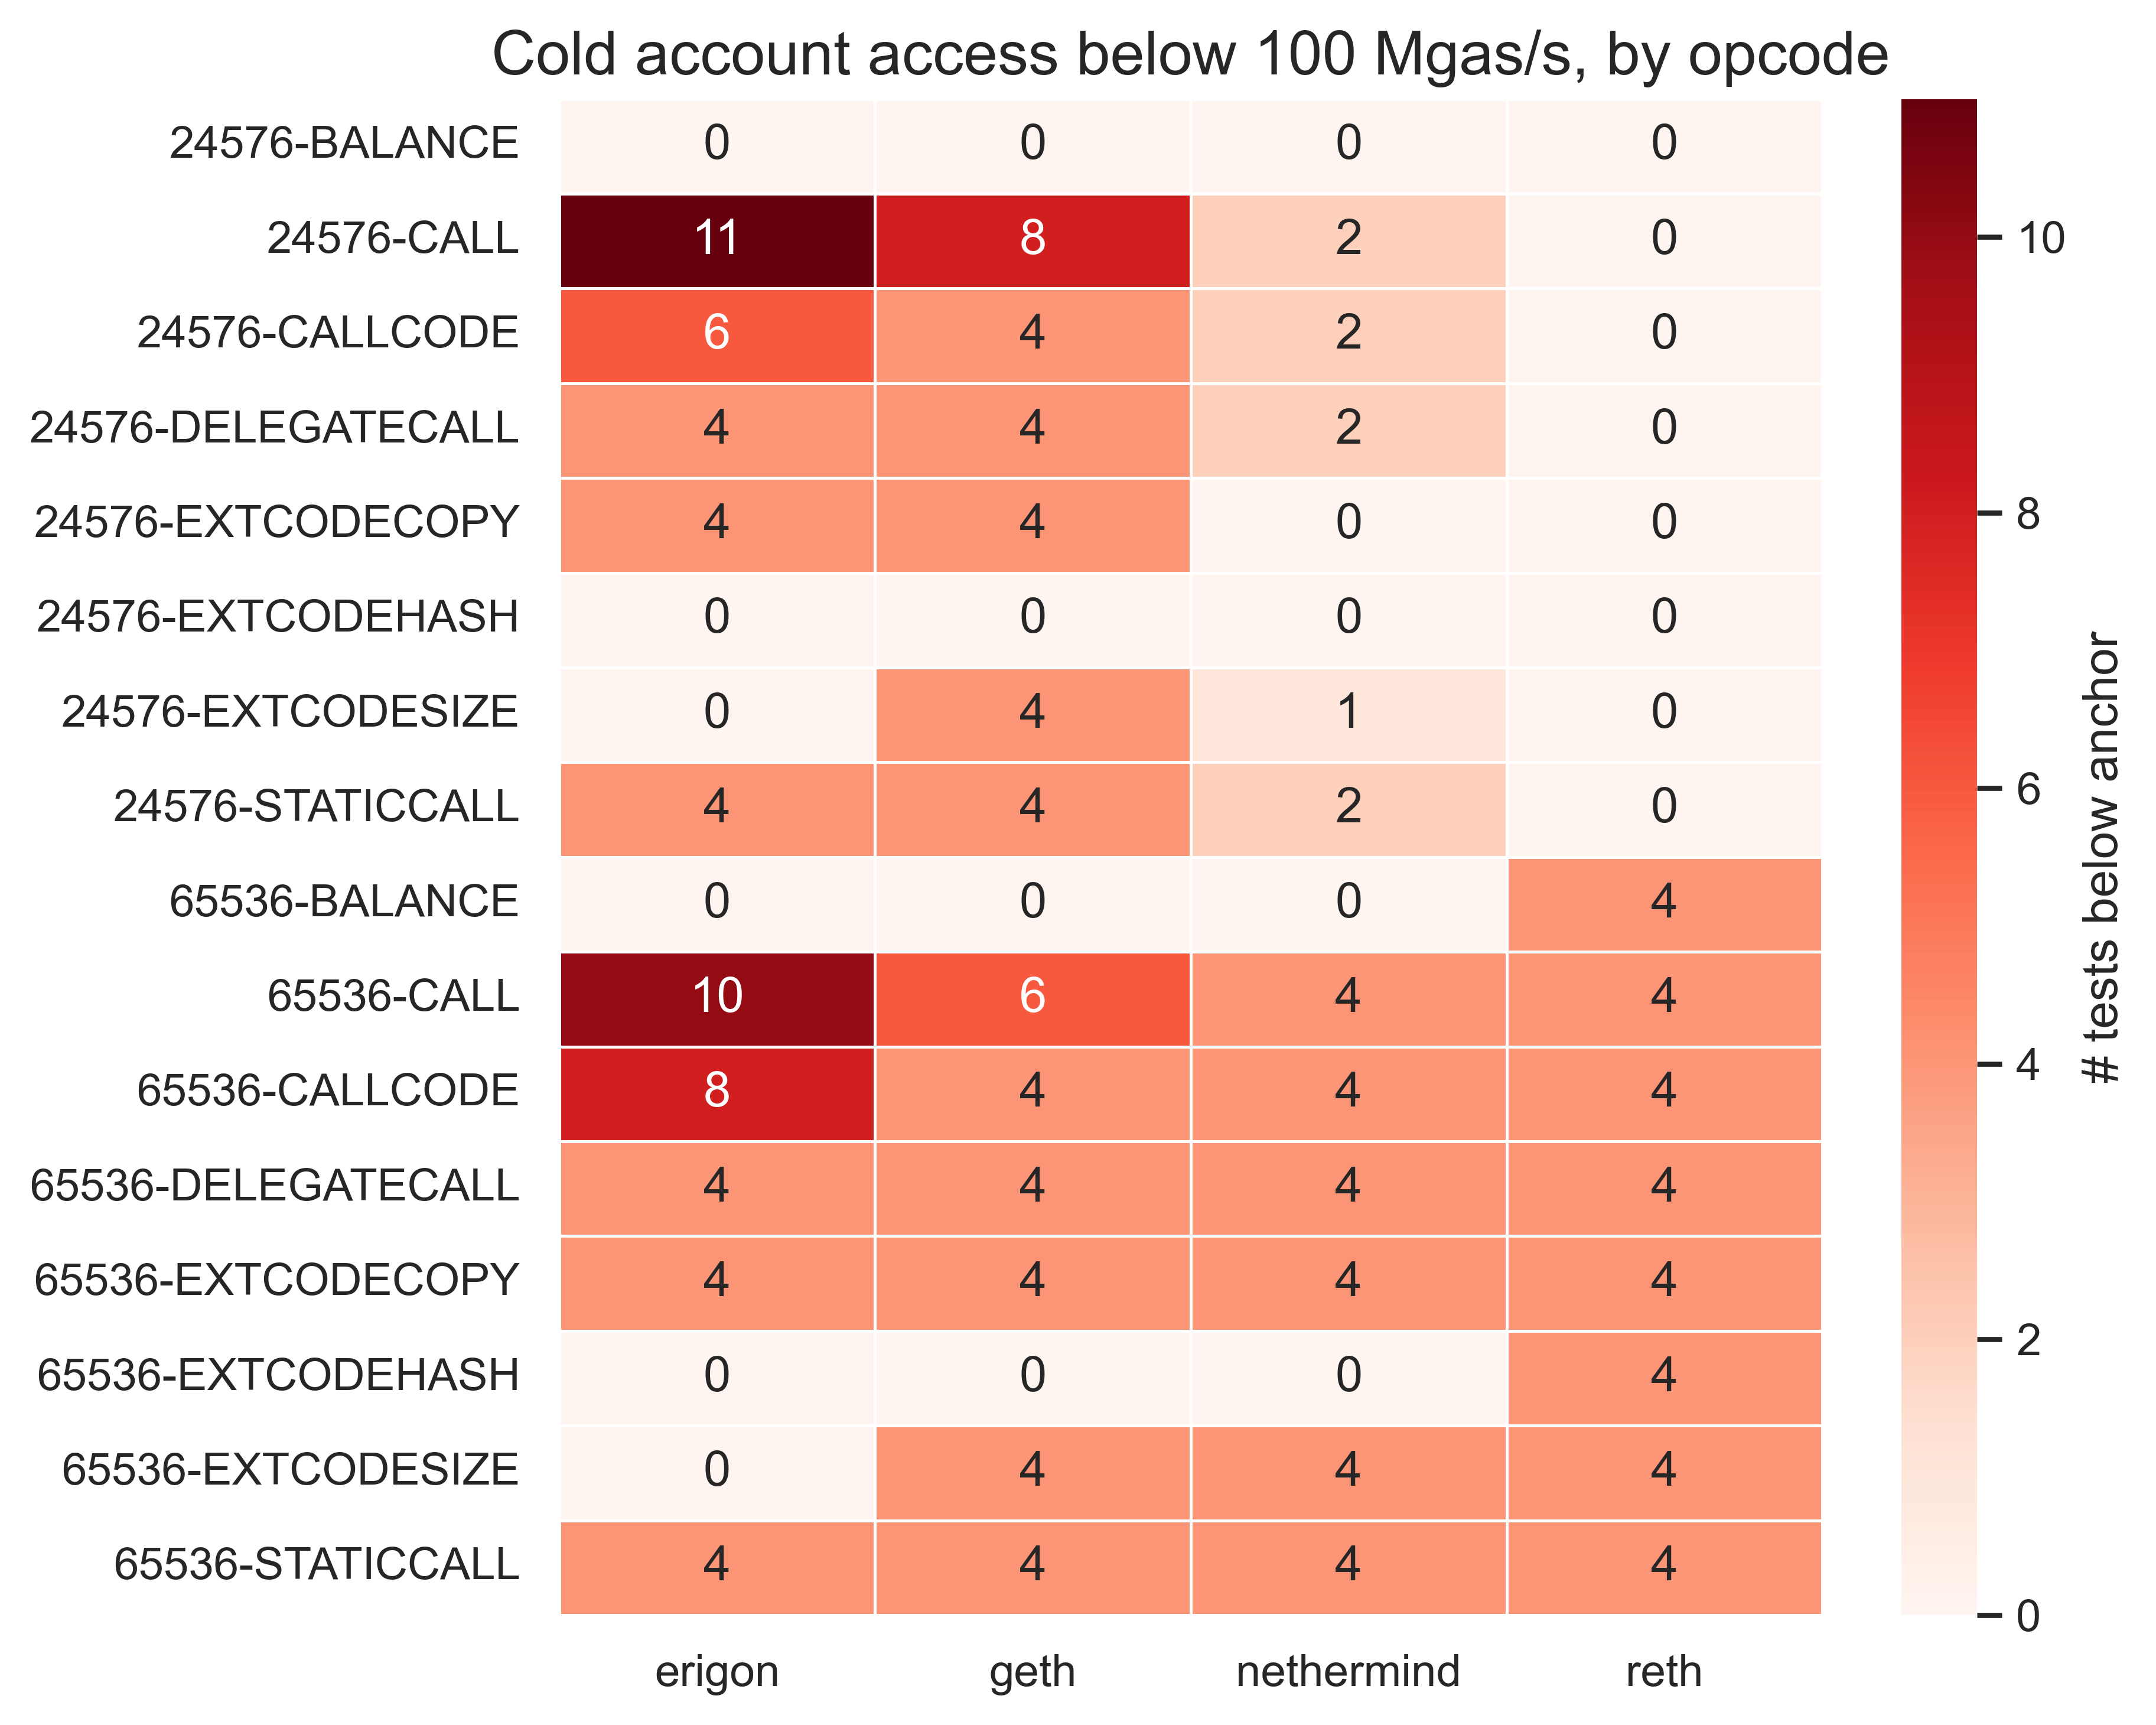

In [21]:
opcode_pivot = account_access_df.pivot_table(
    index=["code_size", "opcode"],
    columns="client",
    values="below_anchor",
    aggfunc="sum",
).reindex(columns=CLIENT_ORDER)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    opcode_pivot,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "# tests below anchor"},
    ax=ax,
)
ax.set_title(f"Cold account access below {ANCHOR_MGAS_S} Mgas/s, by opcode")
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [22]:
display(
    account_access_df.pivot_table(
        index="value_sent", columns="client", values="below_anchor", aggfunc="sum"
    )
    .reindex(columns=CLIENT_ORDER)
    .rename(index={"0": "no value", "1": "value sent"})
)

client,erigon,geth,nethermind,reth
value_sent,,,,
no value,40,48,33,32
value sent,19,6,0,0


The `CALL` family (`CALL`, `CALLCODE`, `DELEGATECALL`, `STATICCALL`) plus
`EXTCODECOPY` are hit on every client; the pure account-query opcodes
(`BALANCE`, `EXTCODEHASH`) only trip `reth` at the large code size, and
`EXTCODESIZE` additionally trips `geth` and `nethermind`. Attaching value to the
call is an `erigon`-specific problem: 19 of its misses are `value_sent_1` cases
(and 6 for `geth`), while `nethermind` and `reth` never miss when value is sent.

### 4.2 `test_ether_transfers_onchain_receivers`

,count,min,median,max
client,,,,
erigon,72,29.9,80.0,343.4
geth,72,76.3,99.9,787.6
nethermind,72,73.4,104.4,630.7
reth,72,146.8,281.8,1394.0


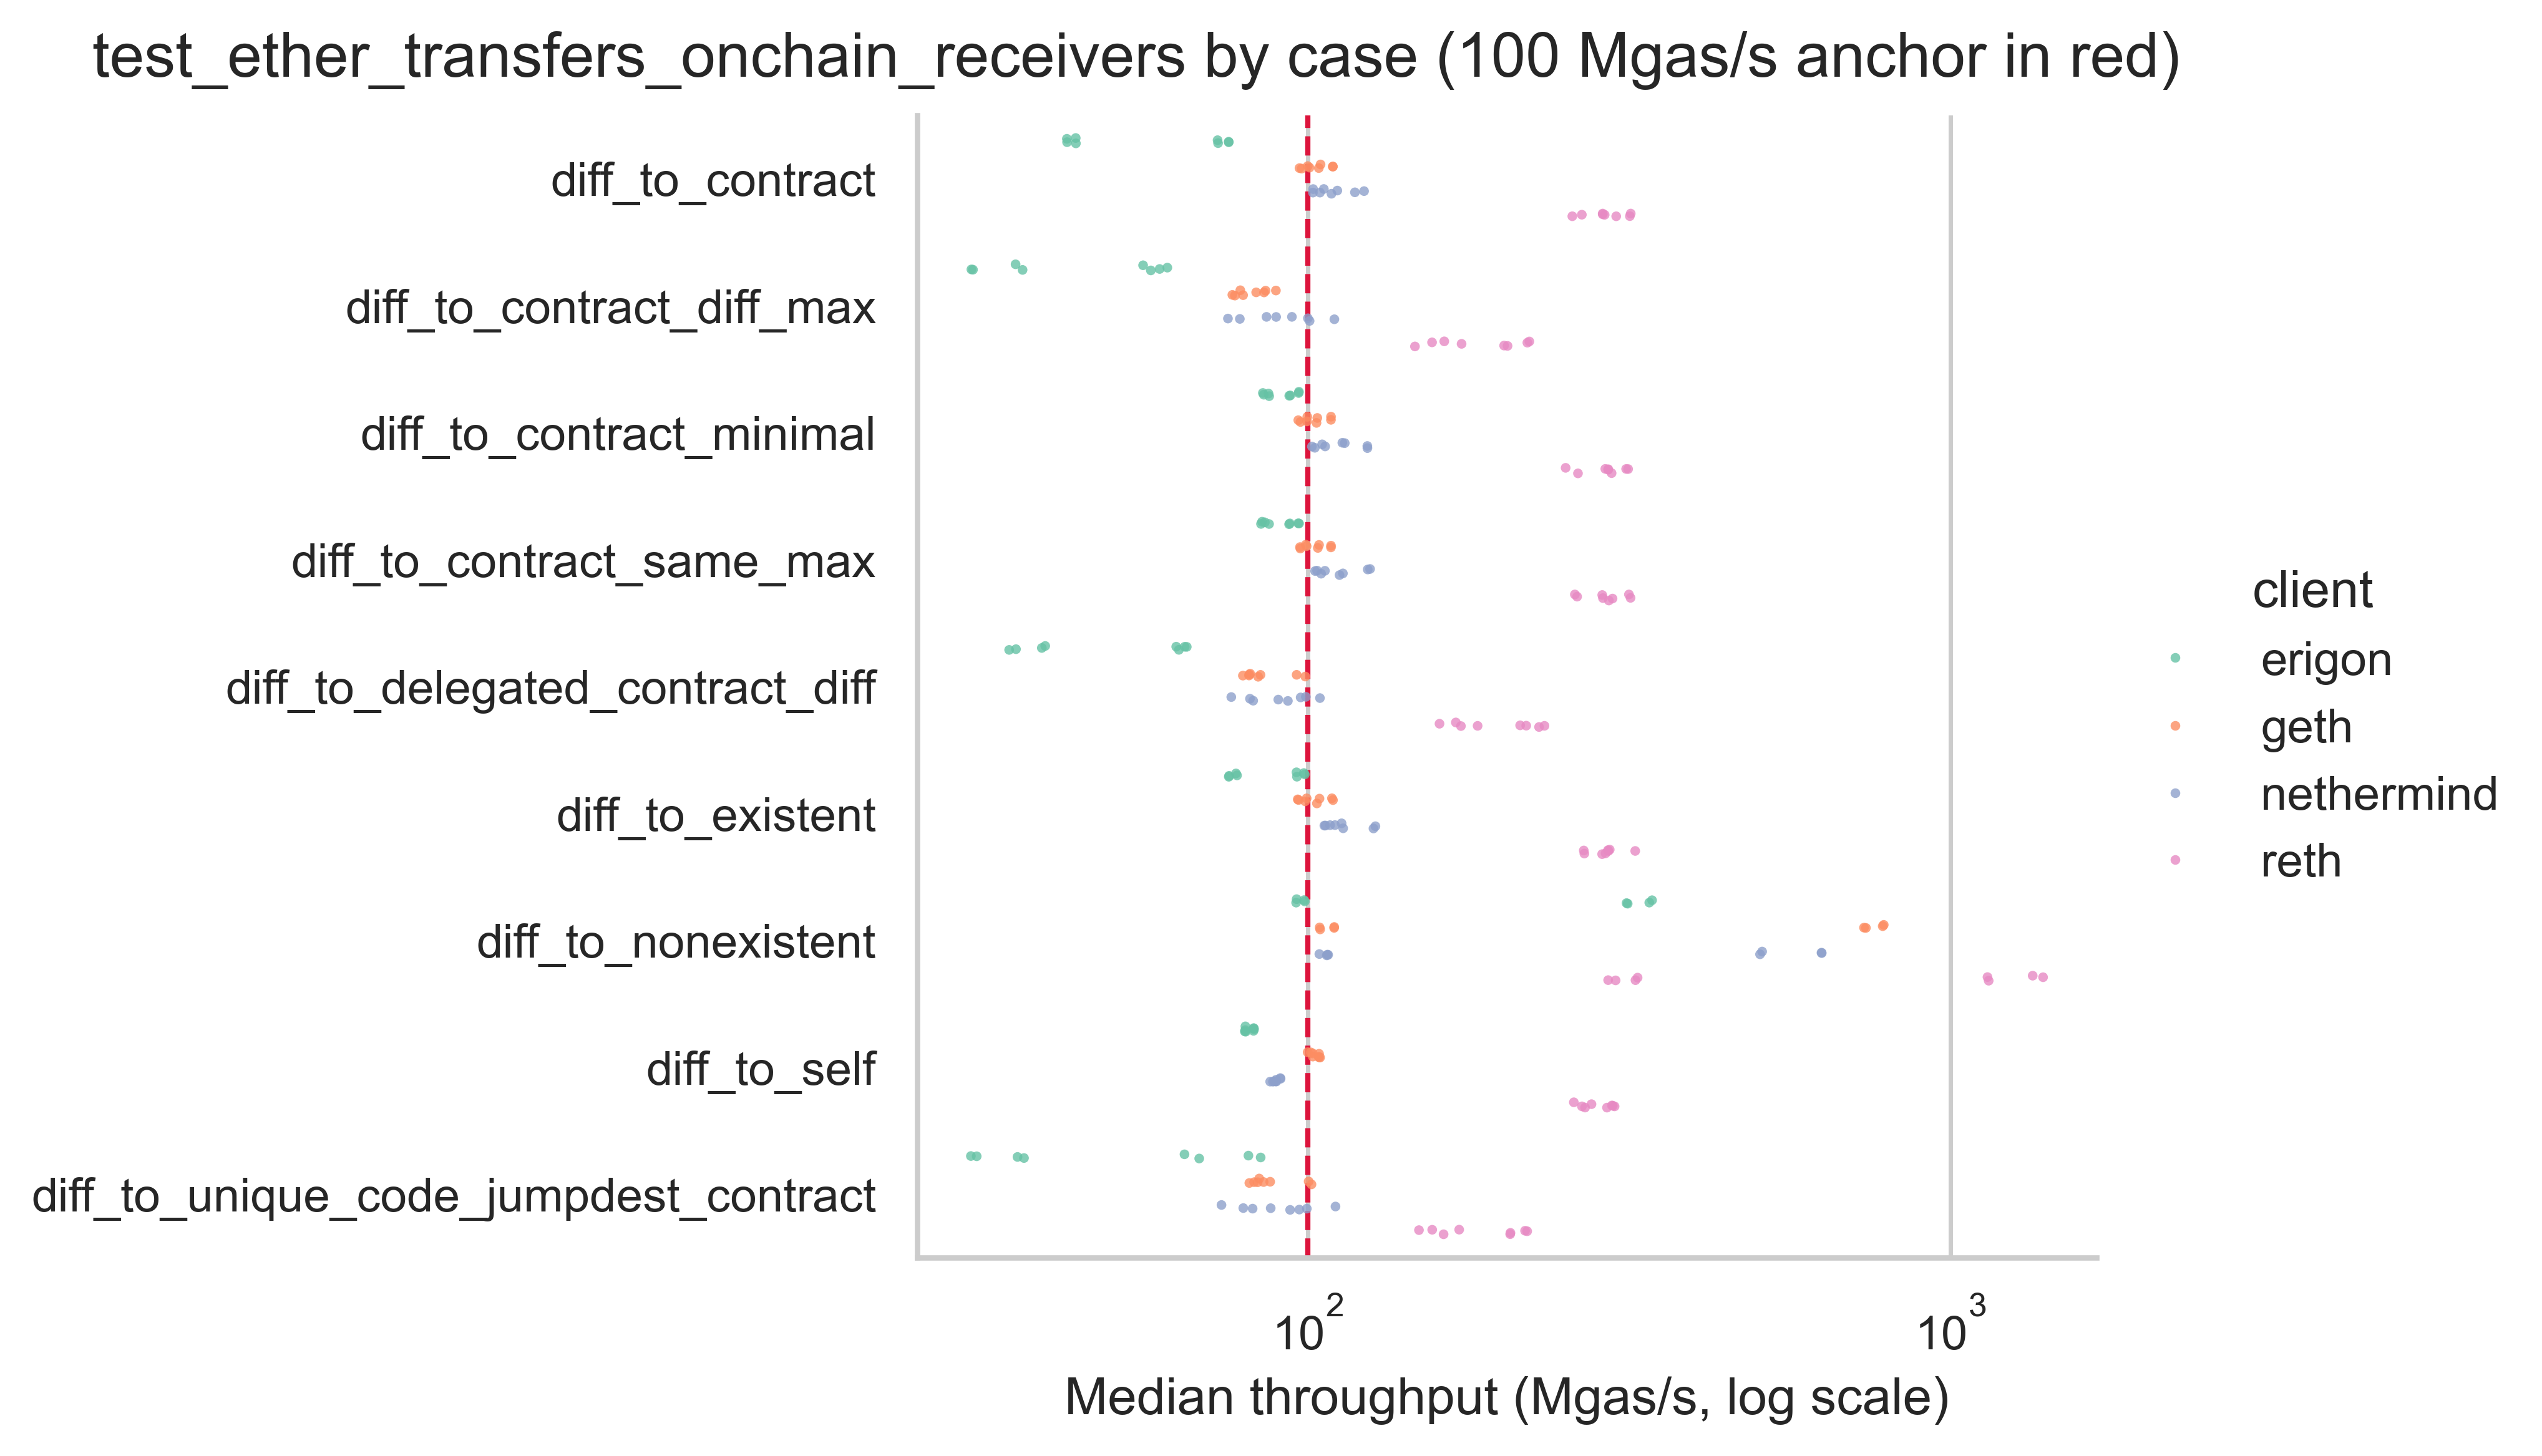

In [23]:
transfers_df = main_df[
    main_df["test_func"] == "test_ether_transfers_onchain_receivers"
].copy()
transfers_df["case_id"] = transfers_df["test_params"].str.extract(
    r"case_id_(.+?)-benchmark"
)
transfers_df["transfer_amount"] = transfers_df["test_params"].str.extract(
    r"transfer_amount_(\d+)"
)

display(
    transfers_df.groupby("client")["median_mgas_s"]
    .agg(["count", "min", "median", "max"])
    .round(1)
    .reindex(CLIENT_ORDER)
)

g = sns.catplot(
    data=transfers_df,
    y="case_id",
    x="median_mgas_s",
    hue="client",
    hue_order=CLIENT_ORDER,
    kind="strip",
    dodge=True,
    height=4.5,
    aspect=1.7,
    s=5,
    alpha=0.8,
)
for ax in g.axes.flat:
    ax.axvline(ANCHOR_MGAS_S, color="crimson", linestyle="--", linewidth=1.2)
    ax.set_xscale("log")
g.set_xlabels("Median throughput (Mgas/s, log scale)")
g.set_ylabels("")
g.figure.suptitle(
    f"test_ether_transfers_onchain_receivers by case "
    f"({ANCHOR_MGAS_S} Mgas/s anchor in red)",
    y=1.02,
)
plt.show()

In [24]:
display(
    transfers_df.pivot_table(
        index="case_id",
        columns="client",
        values=["below_anchor", "median_mgas_s"],
        aggfunc={"below_anchor": "sum", "median_mgas_s": "min"},
    ).round(1)
)

below_anchor                       \
client                                      erigon geth nethermind reth   
case_id                                                                   
diff_to_contract                                 8    3          0    0   
diff_to_contract_diff_max                        8    8          5    0   
diff_to_contract_minimal                         8    4          0    0   
diff_to_contract_same_max                        8    4          0    0   
diff_to_delegated_contract_diff                  8    8          7    0   
diff_to_existent                                 8    4          0    0   
diff_to_nonexistent                              4    0          0    0   
diff_to_self                                     8    1          8    0   
diff_to_unique_code_jumpdest_contract            8    6          7    0   

                                      median_mgas_s                           
client                                       erigon   geth nethermind   reth  
case_id                                                                       
diff_to_contract                               42.2   97.1      101.9  258.1  
diff_to_contract_diff_max                      30.0   76.3       75.1  146.8  
diff_to_contract_minimal                       85.1   96.7      101.5  251.9  
diff_to_contract_same_max                      84.6   97.3      102.7  260.4  
diff_to_delegated_contract_diff                34.3   79.3       76.0  160.3  
diff_to_existent                               75.4   96.5      106.1  268.9  
diff_to_nonexistent                            95.9  104.4      104.2  293.4  
diff_to_self                                   79.8  100.0       87.4  259.5  
diff_to_unique_code_jumpdest_contract          29.9   81.1       73.4  149.0

`reth` clears every transfer case with a 1.5x margin at worst (147 Mgas/s), but
the other three sit right on top of the anchor: `erigon` misses 68 of 72 cases
(median 80 Mgas/s, down to 30), `geth` 38 and `nethermind` 27. The three worst
cases are identical across clients — `diff_to_contract_diff_max`,
`diff_to_delegated_contract_diff` and `diff_to_unique_code_jumpdest_contract`,
i.e. transfers whose receiver is a *large, distinct* contract. These are
**marginal** misses shared by three of four clients, which points at the gas
schedule for on-chain ether transfers rather than a single implementation.

### 4.3 Storage benchmarks

The only remaining misses are in the 10GB bloated-storage families.

In [25]:
storage_below_df = main_df[
    main_df["test_func"].str.contains("sload|sstore|tstore") & main_df["below_anchor"]
].sort_values("median_mgas_s")

display(
    storage_below_df[
        ["client", "test_func", "test_params", "median_mgas_s", "min_mgas_s", "n_runs"]
    ]
    .assign(
        test_params=lambda d: d["test_params"].str.replace(
            "fork_Amsterdam-blockchain_test_stateful_engine-", "", regex=False
        ),
        median_mgas_s=lambda d: d["median_mgas_s"].round(1),
        min_mgas_s=lambda d: d["min_mgas_s"].round(1),
    )
    .reset_index(drop=True)
)

,client,test_func,test_params,median_mgas_s,min_mgas_s,n_runs
0,geth,test_sload_bloated,10GB-cache_strategy_CacheStrategy.NO_CACHE-exi...,81.4,77.2,18
1,geth,test_sstore_bloated,10GB-cache_strategy_CacheStrategy.NO_CACHE-exi...,81.6,75.2,18
2,geth,test_sload_bloated,10GB-cache_strategy_CacheStrategy.NO_CACHE-exi...,83.7,77.5,18
3,geth,test_sstore_bloated,10GB-cache_strategy_CacheStrategy.NO_CACHE-exi...,83.9,78.0,18
4,geth,test_sstore_bloated,10GB-cache_strategy_CacheStrategy.NO_CACHE-exi...,86.5,85.5,18
5,geth,test_sload_bloated,10GB-cache_strategy_CacheStrategy.NO_CACHE-exi...,86.9,82.6,18
6,geth,test_sstore_bloated,10GB-cache_strategy_CacheStrategy.NO_CACHE-exi...,88.6,84.7,18
7,erigon,test_sstore_bloated,10GB-cache_strategy_CacheStrategy.NO_CACHE-exi...,89.3,88.3,12
8,geth,test_sload_bloated,10GB-cache_strategy_CacheStrategy.NO_CACHE-exi...,89.8,83.6,18
9,erigon,test_sstore_bloated,10GB-cache_strategy_CacheStrategy.NO_CACHE-exi...,97.1,96.2,12


These are `geth`-specific (8 of the 10): cold `SLOAD`/`SSTORE` against a 10GB
bloated state runs at 81-90 Mgas/s on `geth` while `erigon`, `nethermind` and
`reth` are at 250-640 Mgas/s on the same tests — a 3-7x gap that looks like a
storage-lookup implementation issue rather than mispricing. `erigon`'s two misses
(`existing_slots_True`, `write_new_value_True`, 89-97 Mgas/s) are marginal.

## 5. Universal vs client-specific shortfalls

If a test is below the anchor for most clients, the gas schedule is the likely
culprit. If it is below for one client only, it is an implementation issue.

In [26]:
per_test_below = (
    main_df.groupby(["test_func", "test_name"])["below_anchor"]
    .agg(n_clients_below="sum", n_clients="size")
    .reset_index()
)

display(per_test_below.groupby("n_clients_below").size().rename("n_tests").to_frame())

,n_tests
n_clients_below,
0,379
1,55
2,48
3,30
4,20


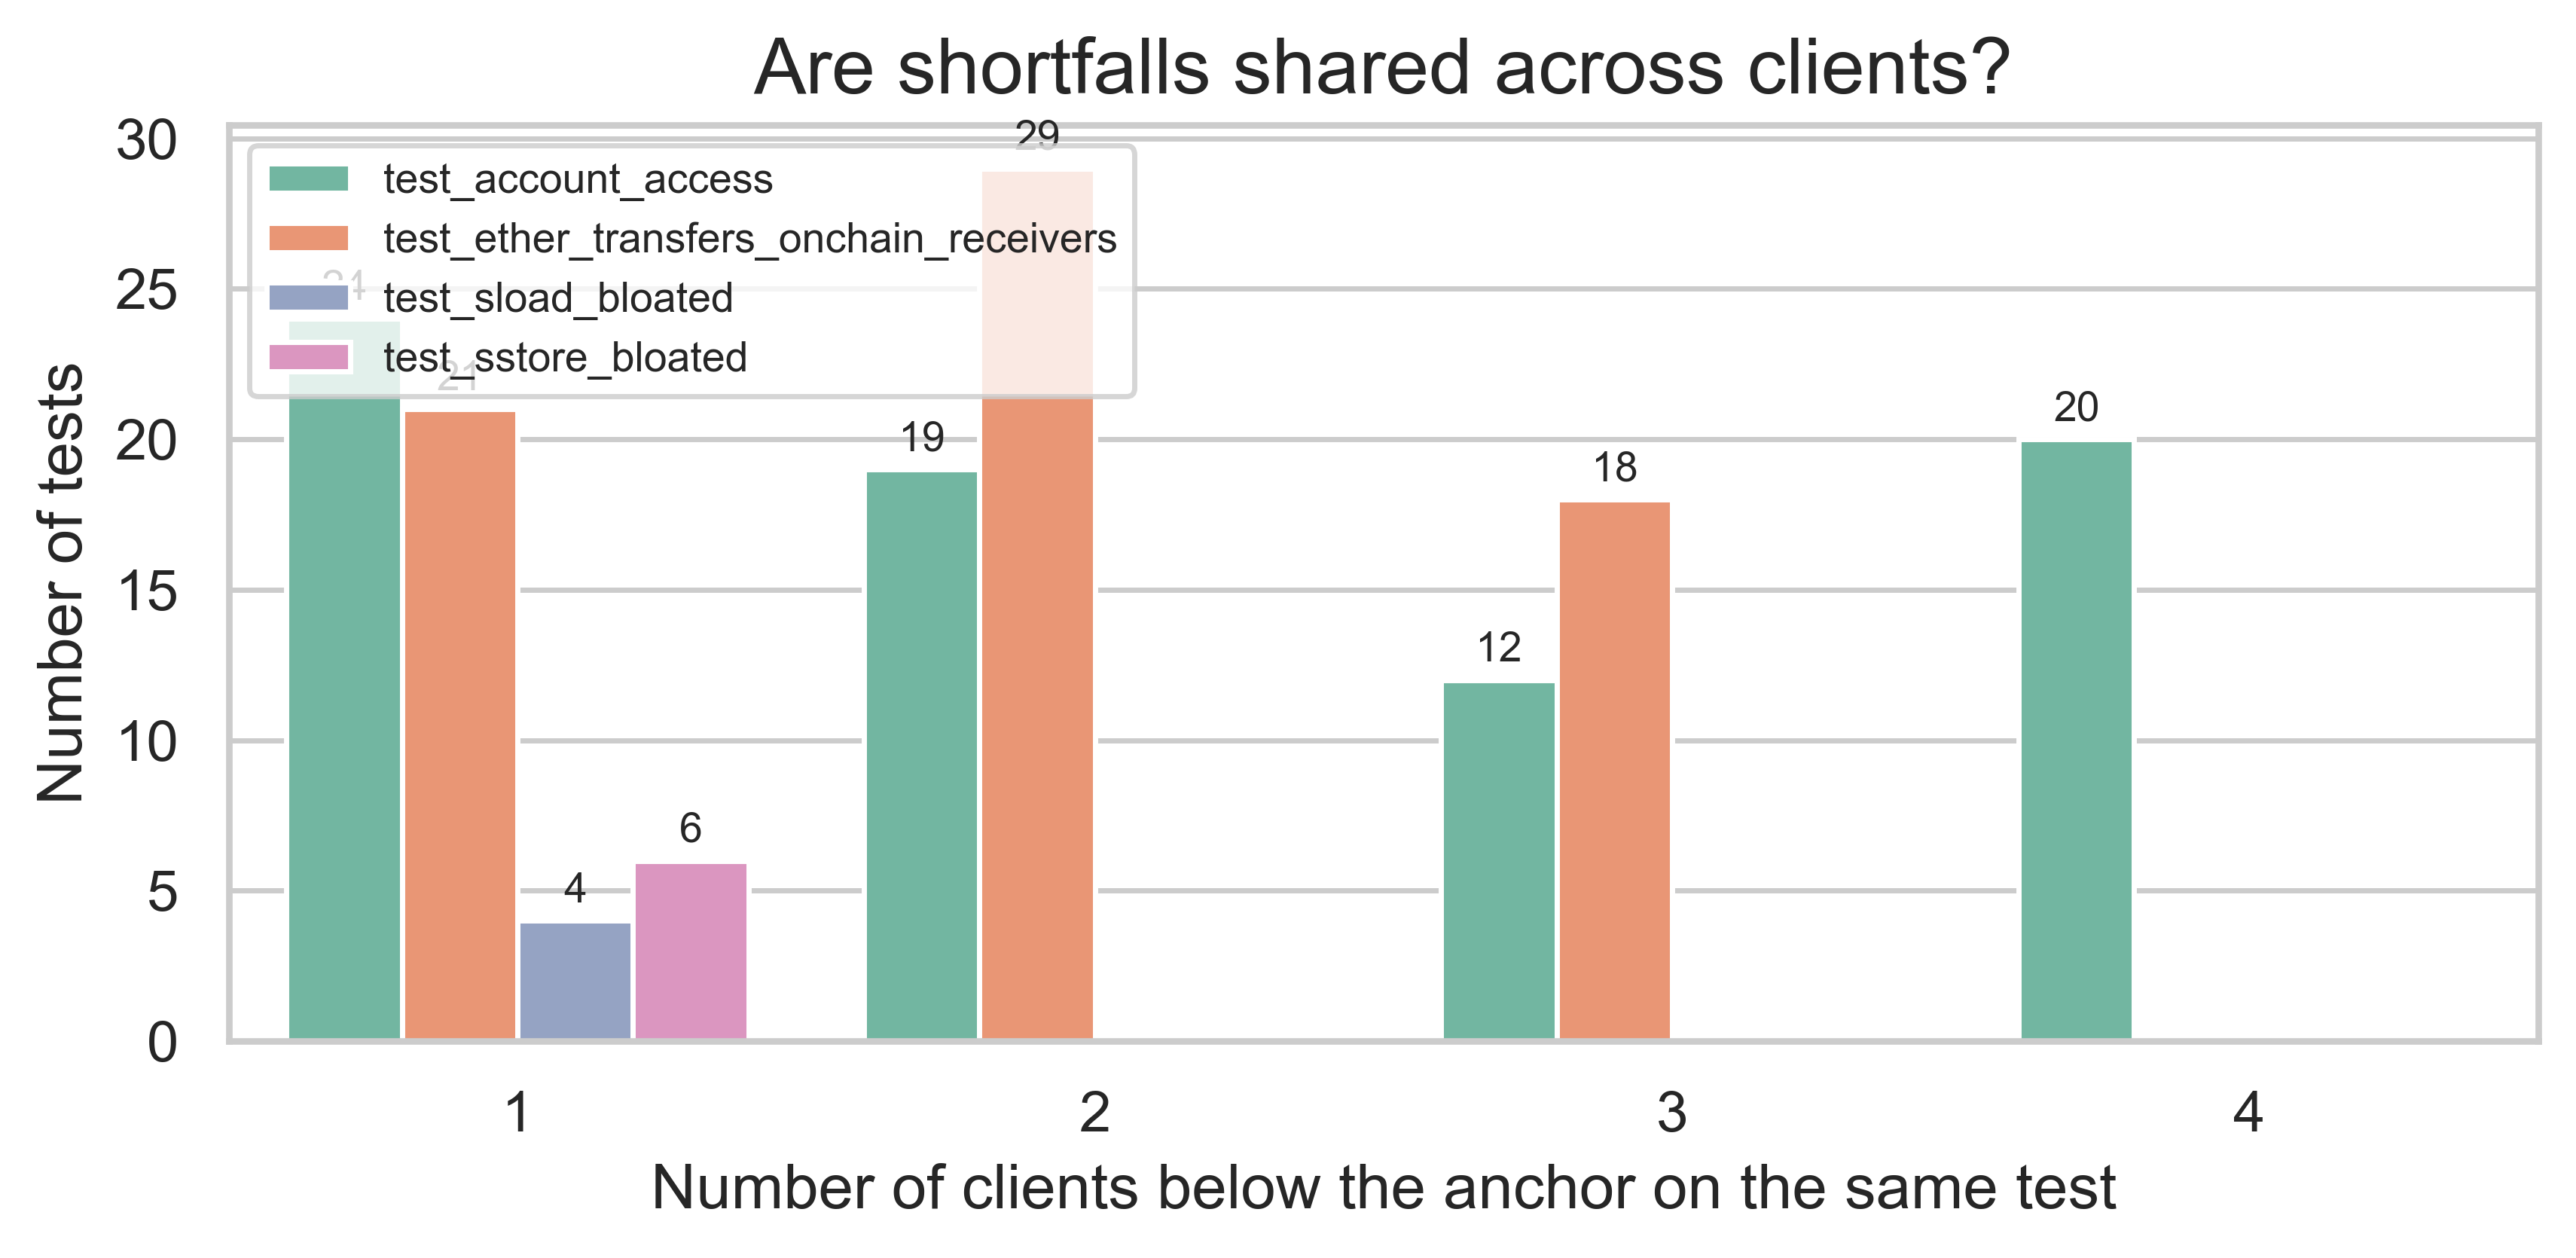

In [27]:
fig, ax = plt.subplots(figsize=(7, 3.5))
count_df = (
    per_test_below[per_test_below["n_clients_below"] > 0]
    .groupby(["test_func", "n_clients_below"])
    .size()
    .rename("n_tests")
    .reset_index()
)
sns.barplot(data=count_df, x="n_clients_below", y="n_tests", hue="test_func", ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2, fontsize=8)
ax.set_xlabel("Number of clients below the anchor on the same test")
ax.set_ylabel("Number of tests")
ax.set_title("Are shortfalls shared across clients?")
sns.move_legend(ax, "upper left", title="", fontsize=8)
plt.tight_layout()
plt.show()

20 tests are below the anchor for all 4 clients:


,n_tests
test_func,
test_account_access,20


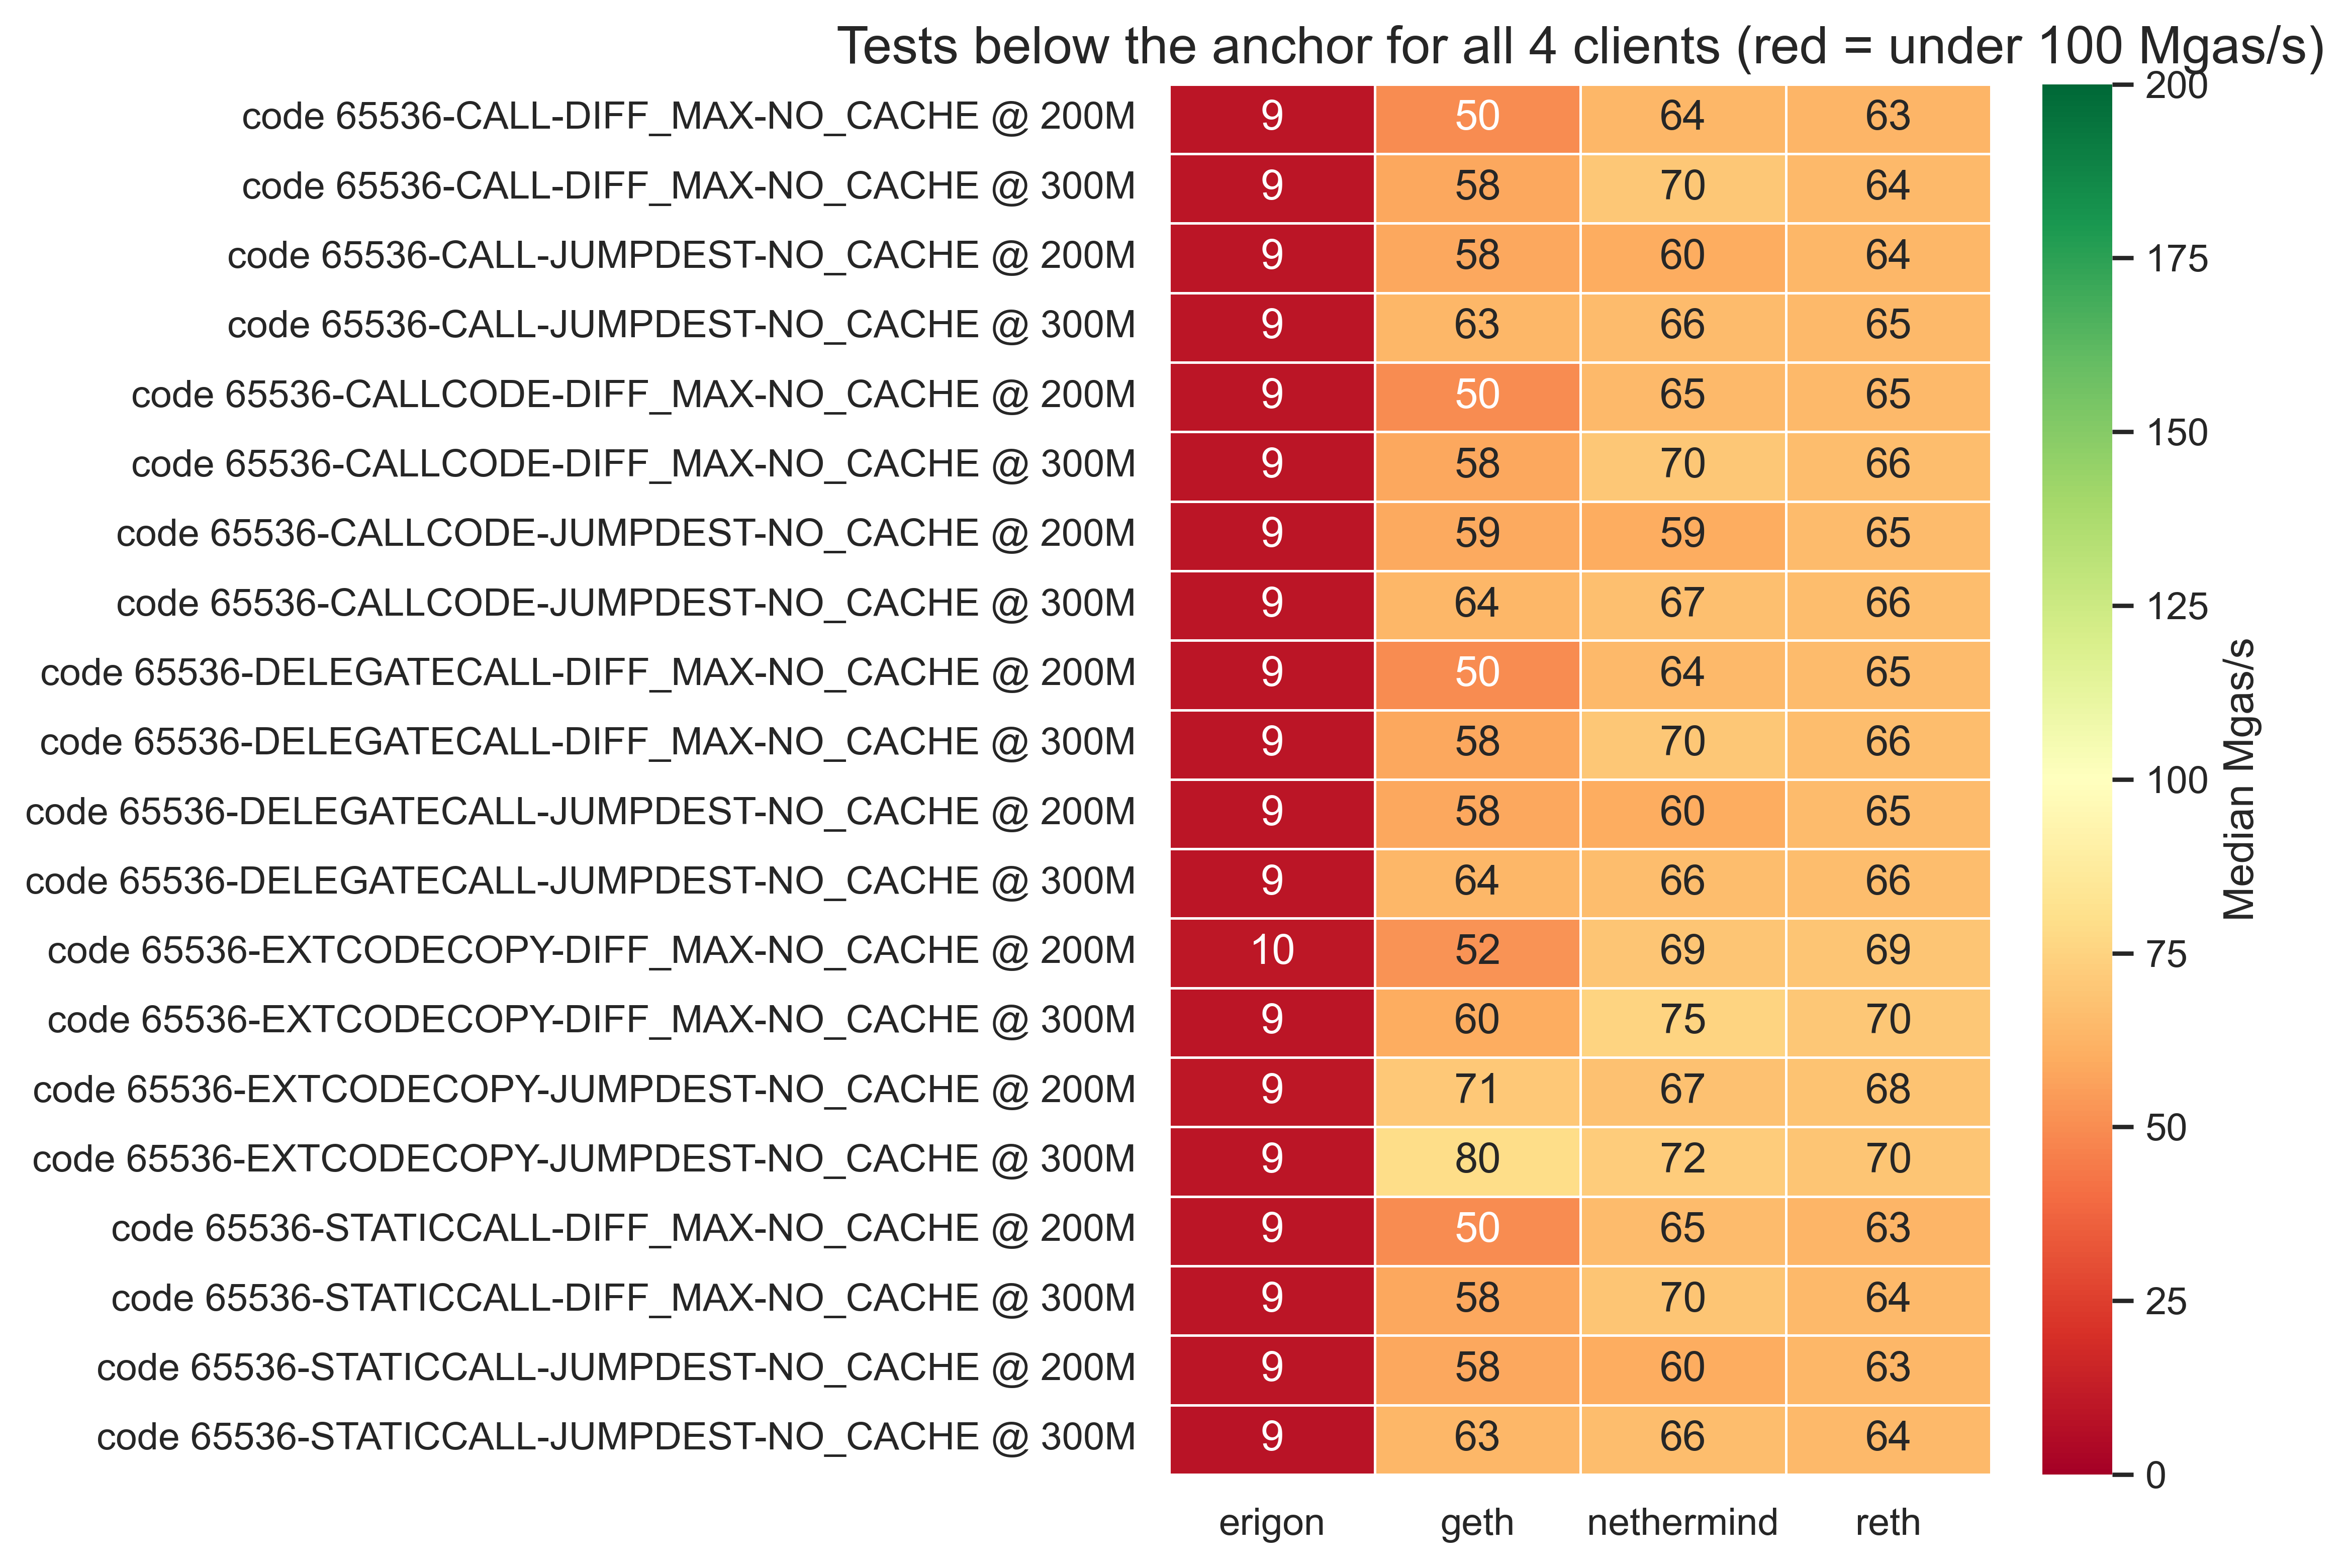

In [28]:
universal_df = per_test_below[per_test_below["n_clients_below"] == 4]
print(f"{len(universal_df)} tests are below the anchor for all 4 clients:")
display(universal_df["test_func"].value_counts().to_frame("n_tests"))

worst_universal = (
    main_df[main_df["test_name"].isin(universal_df["test_name"])]
    .pivot_table(index="test_params", columns="client", values="median_mgas_s")
    .reindex(columns=CLIENT_ORDER)
)
label_replacements = {
    "fork_Amsterdam-blockchain_test_stateful_engine-": "",
    "overhead_baseline_False-": "",
    "cache_strategy_CacheStrategy.NO_CACHE": "NO_CACHE",
    "account_mode_AccountMode.EXISTING_CONTRACT_": "",
    "code_size_": "code ",
    "opcode_": "",
    "value_sent_0-": "",
    "-benchmark-gas-value_": " @ ",
}


def shorten_params(params: str) -> str:
    """Strip the boilerplate shared by every test id so labels stay readable."""
    for old, new in label_replacements.items():
        params = params.replace(old, new)
    return params


worst_universal.index = [shorten_params(i) for i in worst_universal.index]

fig, ax = plt.subplots(figsize=(9, max(3, 0.32 * len(worst_universal))))
sns.heatmap(
    worst_universal,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=ANCHOR_MGAS_S,
    vmin=0,
    vmax=2 * ANCHOR_MGAS_S,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Median Mgas/s"},
    ax=ax,
)
ax.set_title(
    f"Tests below the anchor for all 4 clients (red = under {ANCHOR_MGAS_S} Mgas/s)"
)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

The 20 tests that every client misses are all the same shape: cold
`CALL`/`CALLCODE`/`DELEGATECALL`/`STATICCALL`/`EXTCODECOPY` into a **65,536-byte**
contract in `DIFF_MAX` or `JUMPDEST` mode. Three of the four clients land in a
tight 50-80 Mgas/s band on them — a consistent ~1.5x mispricing — while `erigon`
is an order of magnitude worse at ~9 Mgas/s. A further 30 tests are below the
anchor for 3 of 4 clients, and 55 for exactly one client (implementation
signals).

## 6. Overhead-baseline variants (reported separately)

For completeness: the `overhead_baseline_True` variants are filled to only ~7M
gas, so they are dominated by fixed per-block cost and are **not** a valid anchor
test.

In [29]:
display(
    baseline_df.groupby("client")
    .agg(
        n_tests=("test_name", "size"),
        n_below=("below_anchor", "sum"),
        min_mgas_s=("median_mgas_s", "min"),
        median_mgas_s=("median_mgas_s", "median"),
    )
    .round(1)
    .reindex(CLIENT_ORDER)
)

,n_tests,n_below,min_mgas_s,median_mgas_s
client,,,,
erigon,160,32,55.5,136.4
geth,160,0,111.8,163.2
nethermind,160,160,34.7,61.5
reth,160,0,126.7,203.0


`nethermind` is below 100 Mgas/s on all 160 baseline variants (median 62) and
`erigon` on 32 of them, which reflects their per-block overhead rather than
execution throughput. `geth` and `reth` clear the anchor on all of them.

## 7. Export the anchor table

In [30]:
export_df = (
    main_df.pivot_table(
        index=["test_func", "test_params"],
        columns="client",
        values="median_mgas_s",
    )
    .reindex(columns=CLIENT_ORDER)
    .round(1)
)
export_df["n_clients_below_anchor"] = (export_df[CLIENT_ORDER] < ANCHOR_MGAS_S).sum(
    axis=1
)
export_df = export_df.sort_values("n_clients_below_anchor", ascending=False)

export_path = os.path.join(
    repo_dir, "data", "median_mgas_s_by_test_and_client_devnet8_2026-09-01.csv"
)
export_df.to_csv(export_path)
print(f"Wrote {len(export_df)} rows to {os.path.relpath(export_path, repo_dir)}")
display(export_df.head(10))

Wrote 532 rows to data/median_mgas_s_by_test_and_client_devnet8_2026-09-01.csv


client                                                                  erigon  \
test_func           test_params                                                  
test_account_access fork_Amsterdam-blockchain_test_stateful_engine-...     8.8   
                    fork_Amsterdam-blockchain_test_stateful_engine-...     8.6   
                    fork_Amsterdam-blockchain_test_stateful_engine-...     8.8   
                    fork_Amsterdam-blockchain_test_stateful_engine-...     8.6   
                    fork_Amsterdam-blockchain_test_stateful_engine-...     9.5   
                    fork_Amsterdam-blockchain_test_stateful_engine-...     9.3   
                    fork_Amsterdam-blockchain_test_stateful_engine-...     9.5   
                    fork_Amsterdam-blockchain_test_stateful_engine-...     9.4   
                    fork_Amsterdam-blockchain_test_stateful_engine-...     8.7   
                    fork_Amsterdam-blockchain_test_stateful_engine-...     9.0   

client                                                                  geth  \
test_func           test_params                                                
test_account_access fork_Amsterdam-blockchain_test_stateful_engine-...  58.0   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  63.3   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  58.2   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  63.8   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  51.9   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  59.9   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  71.1   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  79.6   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  57.8   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  49.6   

client                                                                  nethermind  \
test_func           test_params                                                      
test_account_access fork_Amsterdam-blockchain_test_stateful_engine-...        69.8   
                    fork_Amsterdam-blockchain_test_stateful_engine-...        65.7   
                    fork_Amsterdam-blockchain_test_stateful_engine-...        59.8   
                    fork_Amsterdam-blockchain_test_stateful_engine-...        65.8   
                    fork_Amsterdam-blockchain_test_stateful_engine-...        69.1   
                    fork_Amsterdam-blockchain_test_stateful_engine-...        75.2   
                    fork_Amsterdam-blockchain_test_stateful_engine-...        67.5   
                    fork_Amsterdam-blockchain_test_stateful_engine-...        72.5   
                    fork_Amsterdam-blockchain_test_stateful_engine-...        69.6   
                    fork_Amsterdam-blockchain_test_stateful_engine-...        64.2   

client                                                                  reth  \
test_func           test_params                                                
test_account_access fork_Amsterdam-blockchain_test_stateful_engine-...  64.4   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  64.4   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  63.5   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  66.0   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  68.8   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  69.8   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  68.5   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  69.5   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  65.8   
                    fork_Amsterdam-blockchain_test_stateful_engine-...  64.9   

client                                                      

## Summary

**Data.** 39,444 per-test throughput measurements from benchmarkoor for the
`glamsterdam-devnet-8` stateful suite (`7eec9e8fcd40b131`,
`jochemnet-glamsterdam-devnet-8-stateful-full`, 692 tests of which 532 are
non-baseline), covering 4 clients over 2026-08-28 → 2026-09-01. Throughput is the
per-test median across runs; `overhead_baseline_True` variants (~7M gas) are
excluded from the anchor check.

**Does everyone clear 100 Mgas/s?** No — nobody does.

| Client | Tests below anchor (of 532) | Slowest test (Mgas/s) | Median test (Mgas/s) |
| --- | --- | --- | --- |
| reth | 32 (6.0%) | 63.2 | 603.9 |
| nethermind | 60 (11.3%) | 59.5 | 537.0 |
| geth | 100 (18.8%) | 49.6 | 148.3 |
| erigon | 129 (24.2%) | 8.6 | 521.4 |

**Where the anchor breaks.**

1. **Cold access to large-code contracts is the dominant gap.**
   `test_account_access` supplies 59/54/33/32 of the misses for
   `erigon`/`geth`/`nethermind`/`reth`, and every one of them is in the
   `EXISTING_CONTRACT_DIFF_MAX` or `EXISTING_CONTRACT_JUMPDEST` account mode —
   the modes that force a real trie lookup against a large contract. Contract
   **code size** is the discriminator: all 32 of `reth`'s misses (and 24 of
   `nethermind`'s 33) are at 65,536 bytes, and both clear far more of the
   24,576-byte cases. The `CALL` family and `EXTCODECOPY` are worst hit.
2. **On-chain ether transfers are marginal for three of four clients.**
   `test_ether_transfers_onchain_receivers` puts `erigon` below on 68 of 72
   cases (down to 30 Mgas/s), `geth` on 38 and `nethermind` on 27, while `reth`
   clears them all at ≥147 Mgas/s. The worst cases are the same everywhere:
   receivers that are large, distinct contracts (`diff_to_contract_diff_max`,
   `diff_to_delegated_contract_diff`, `diff_to_unique_code_jumpdest_contract`).
3. **`geth` has a bloated-storage gap.** Cold `SLOAD`/`SSTORE` against 10GB of
   bloated state runs at 81-90 Mgas/s on `geth` while the other three clients sit
   at 250-640 Mgas/s — a 3-7x gap that reads as an implementation issue.
4. **`erigon` has a pathological cold-CALL case.** At 65,536-byte code size its
   cold `CALL`-family tests run at **8.6-9.5 Mgas/s**, ~10x slower than the other
   clients on the identical tests, so most of its 129 misses are an `erigon`
   problem rather than a pricing one.
5. **Everything else is comfortable.** Warm account queries
   (`ext_account_query_warm`, 112 tests), `create2_immediate_access`,
   `sstore_variants`, `sstore_dirty_transitions`, `call_value_to_empty` and all
   `tstore_*` benchmarks clear the anchor on every client, and per-client median
   throughput sits 1.5-6x above the anchor.

**Shared vs client-specific.** 20 tests are below the anchor for all 4 clients
and 30 more for 3 of 4 — all cold `test_account_access` and large-receiver
transfers, i.e. pricing signals. 55 tests fail for exactly one client — those are
implementation signals.

**Caveats.** Only 4 clients run this suite; `besu` and `ethrex` have no completed
devnet-8 stateful runs, so the devnet-7 picture for them cannot be refreshed
here. Repetition counts are modest (12-18 runs per client) but even, every client
runs a single pinned `glamsterdam-devnet-8` image on its own dedicated instance,
and all 692 tests pass in every run — so unlike devnet-7 there are no failed
tests silently dropping out of any client's results. Comparisons with the
devnet-7 notebook should also account for the different anchor (100 vs
75 Mgas/s) and a substantially reworked stateful test set (532 vs 374
non-baseline tests, with a new `code_size` dimension).